# Index Design and Scaling

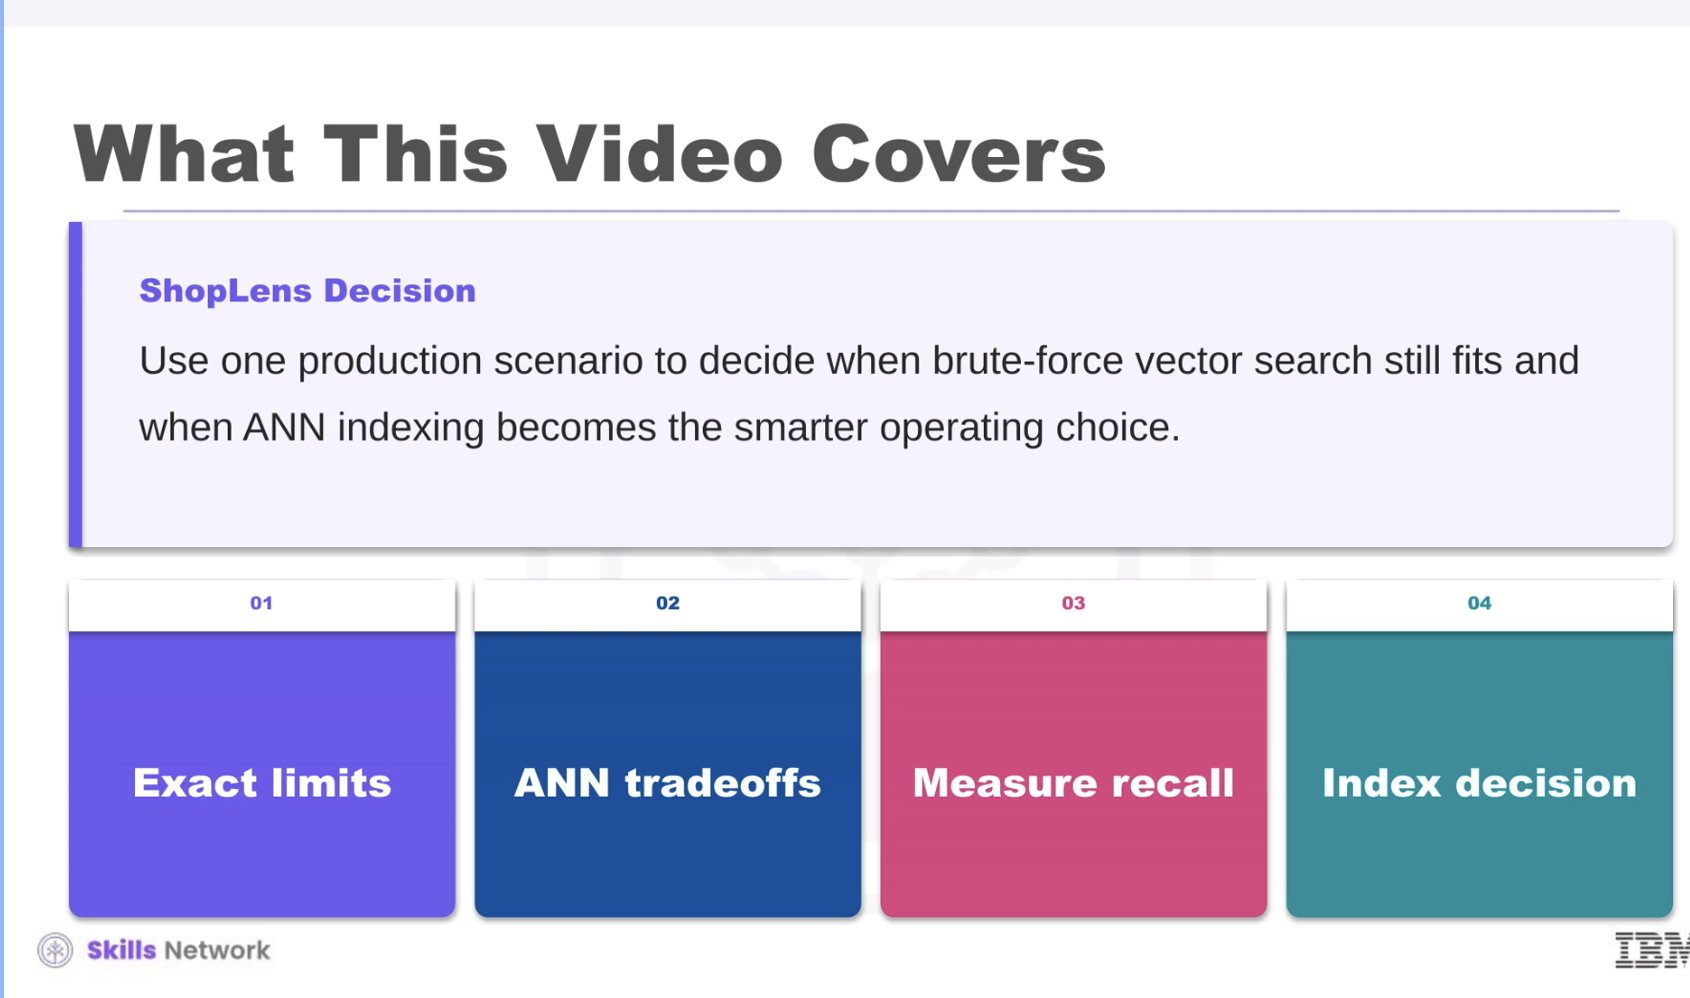
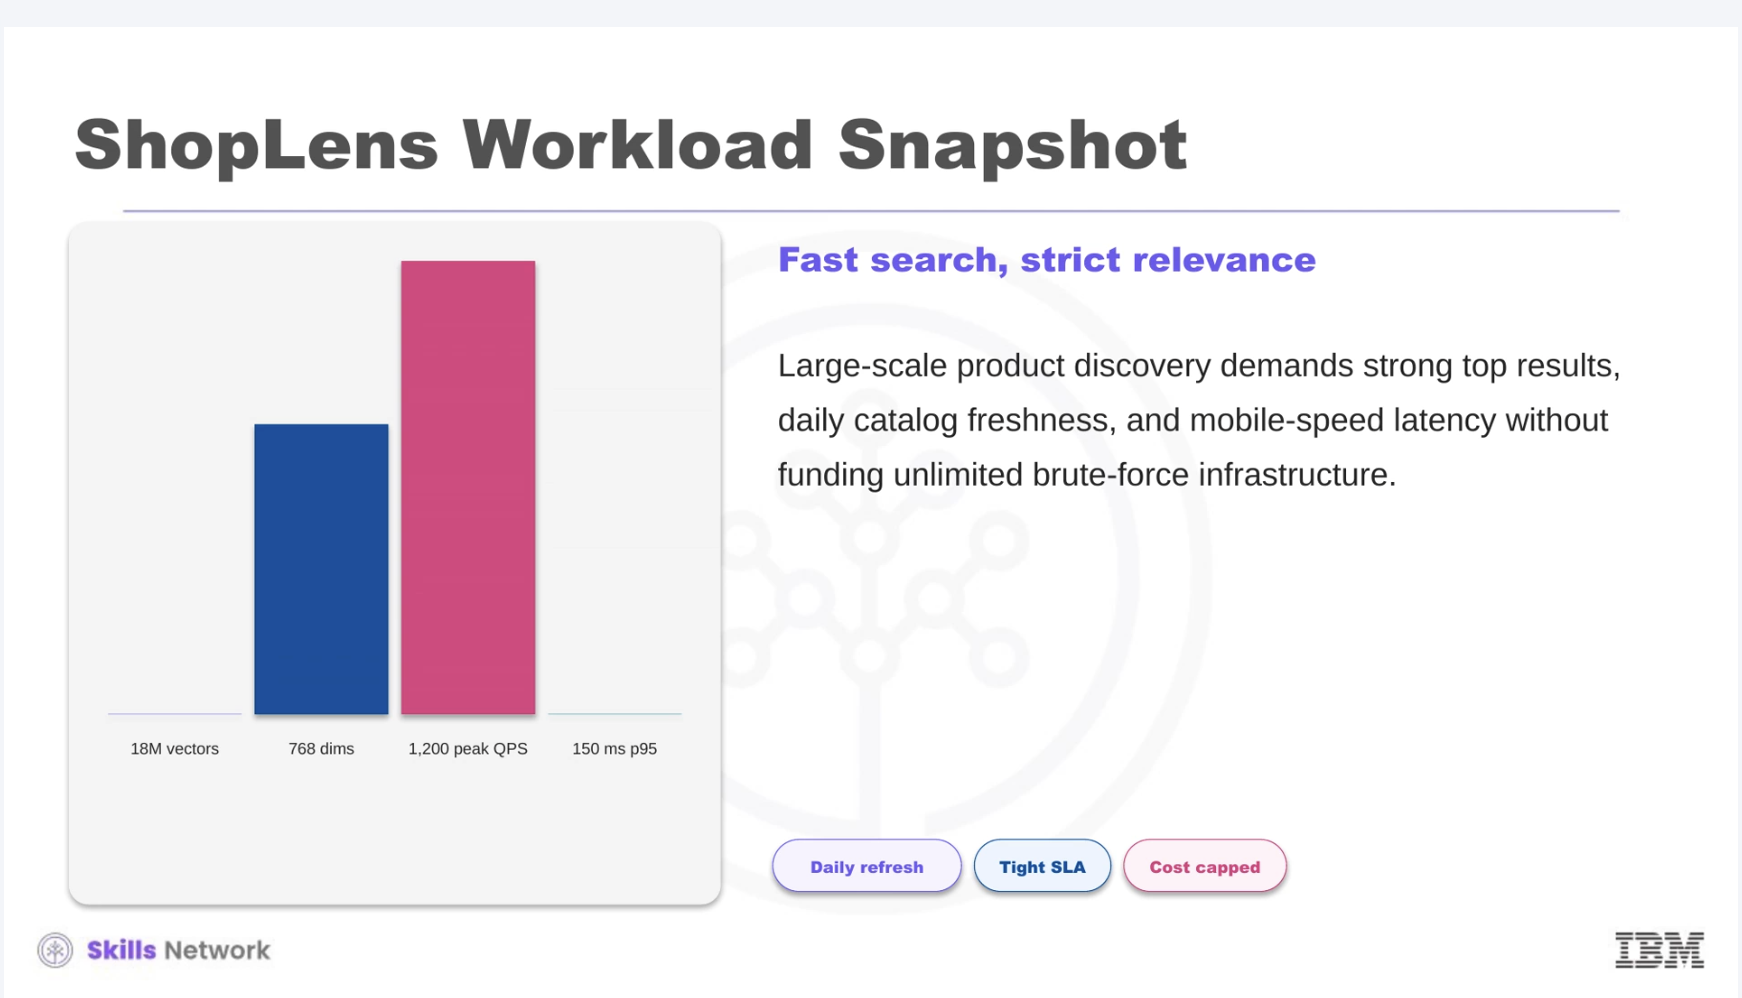
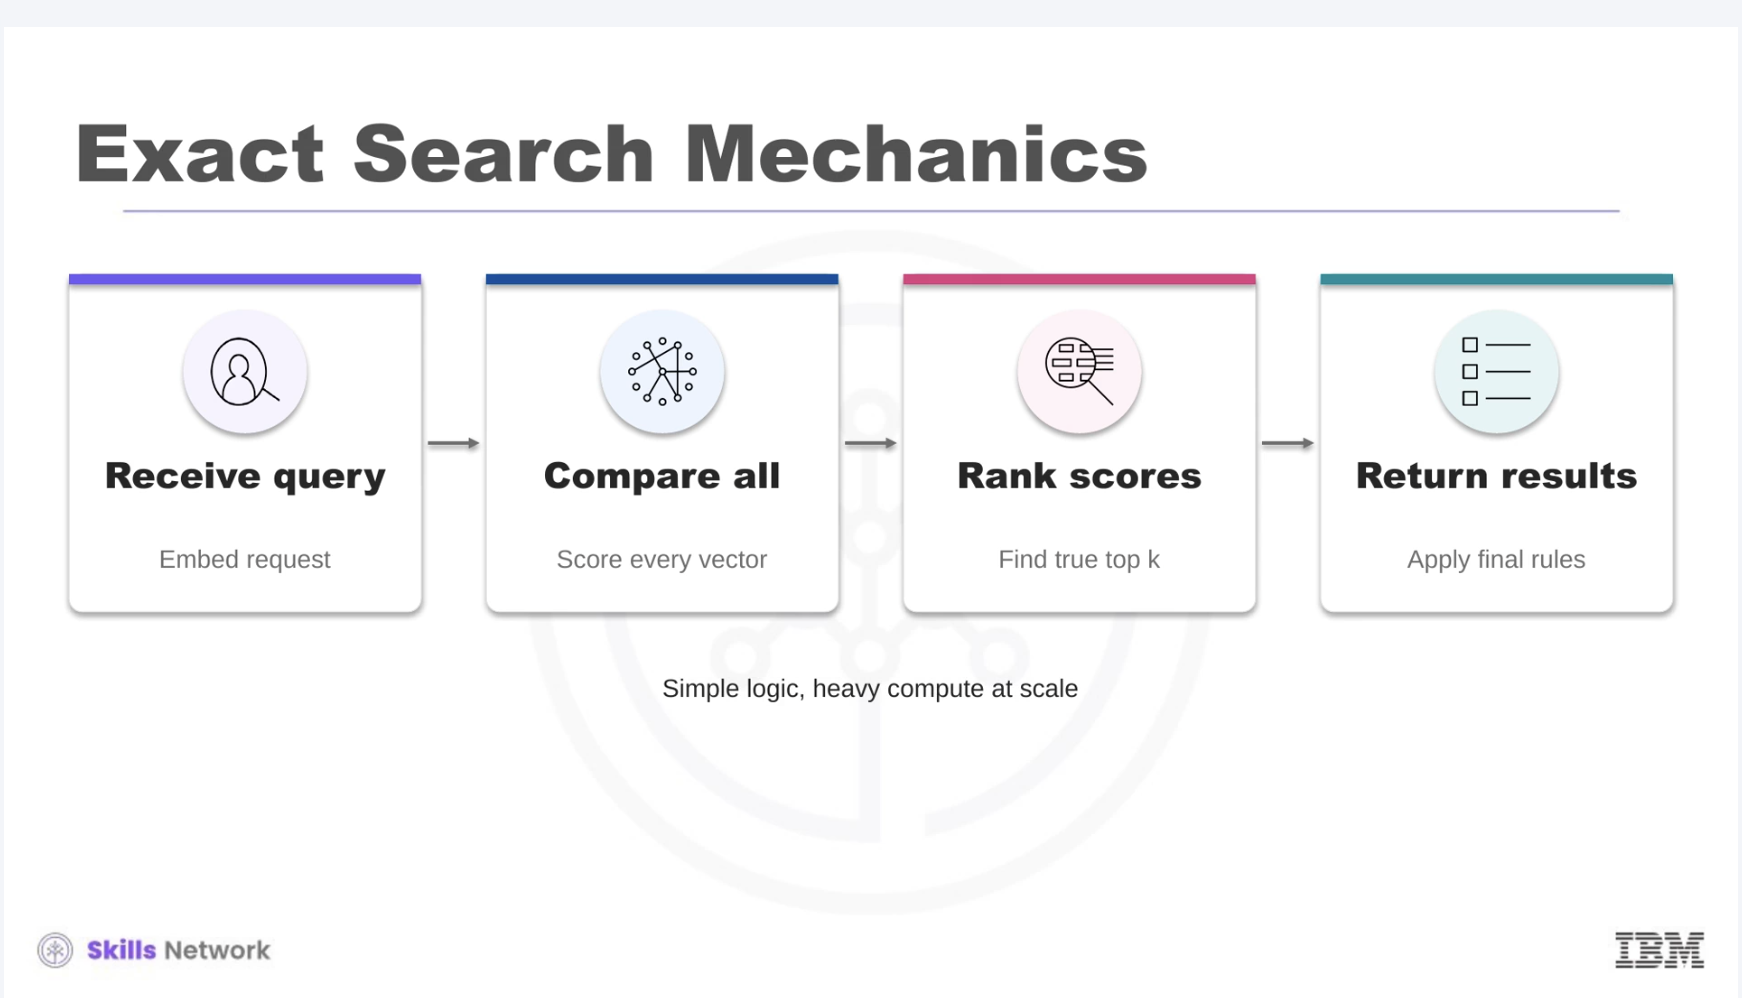
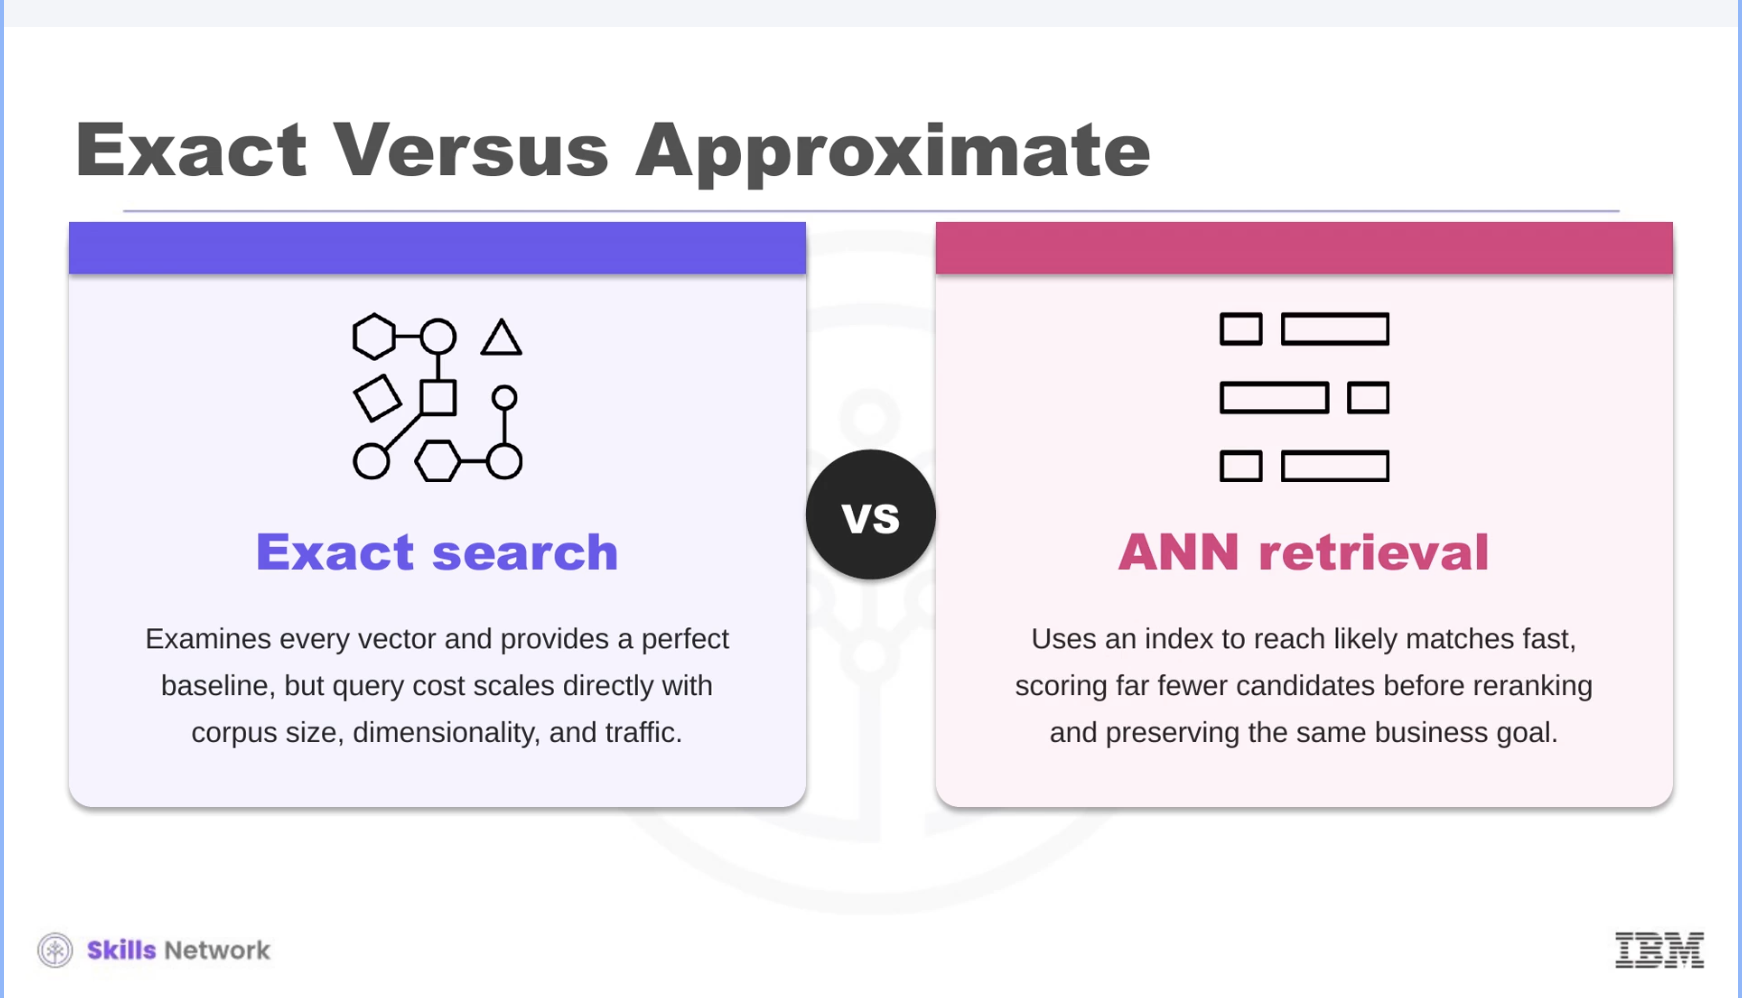
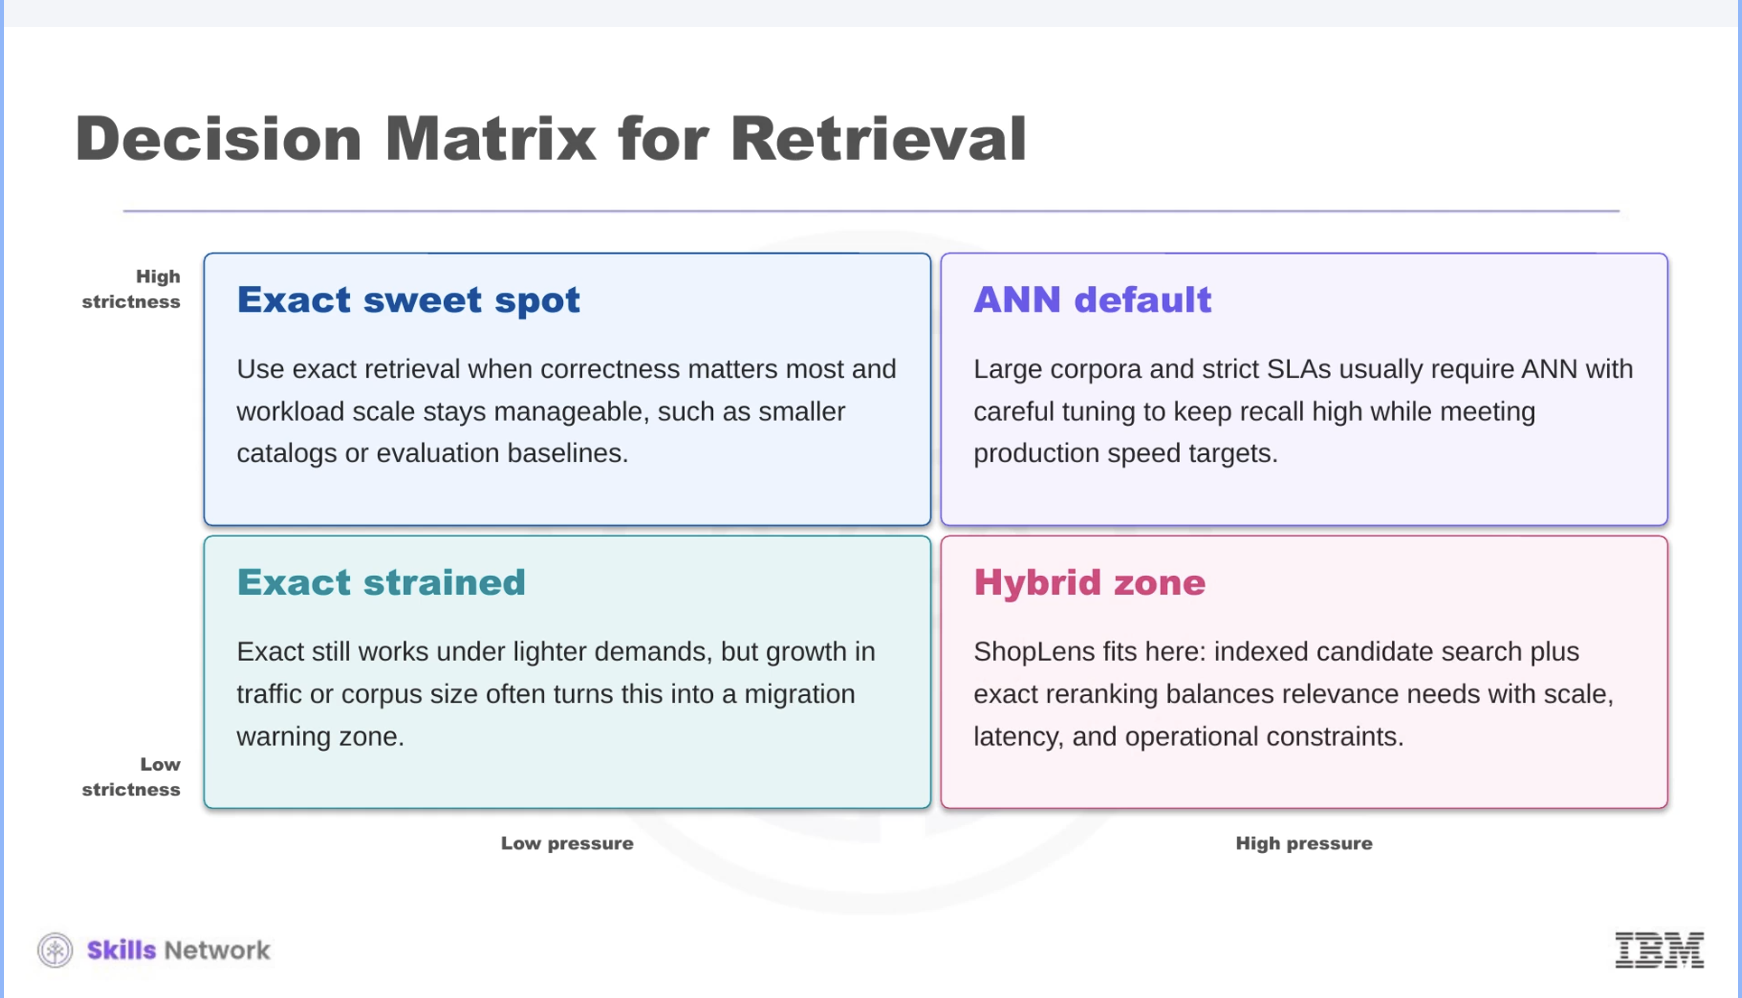
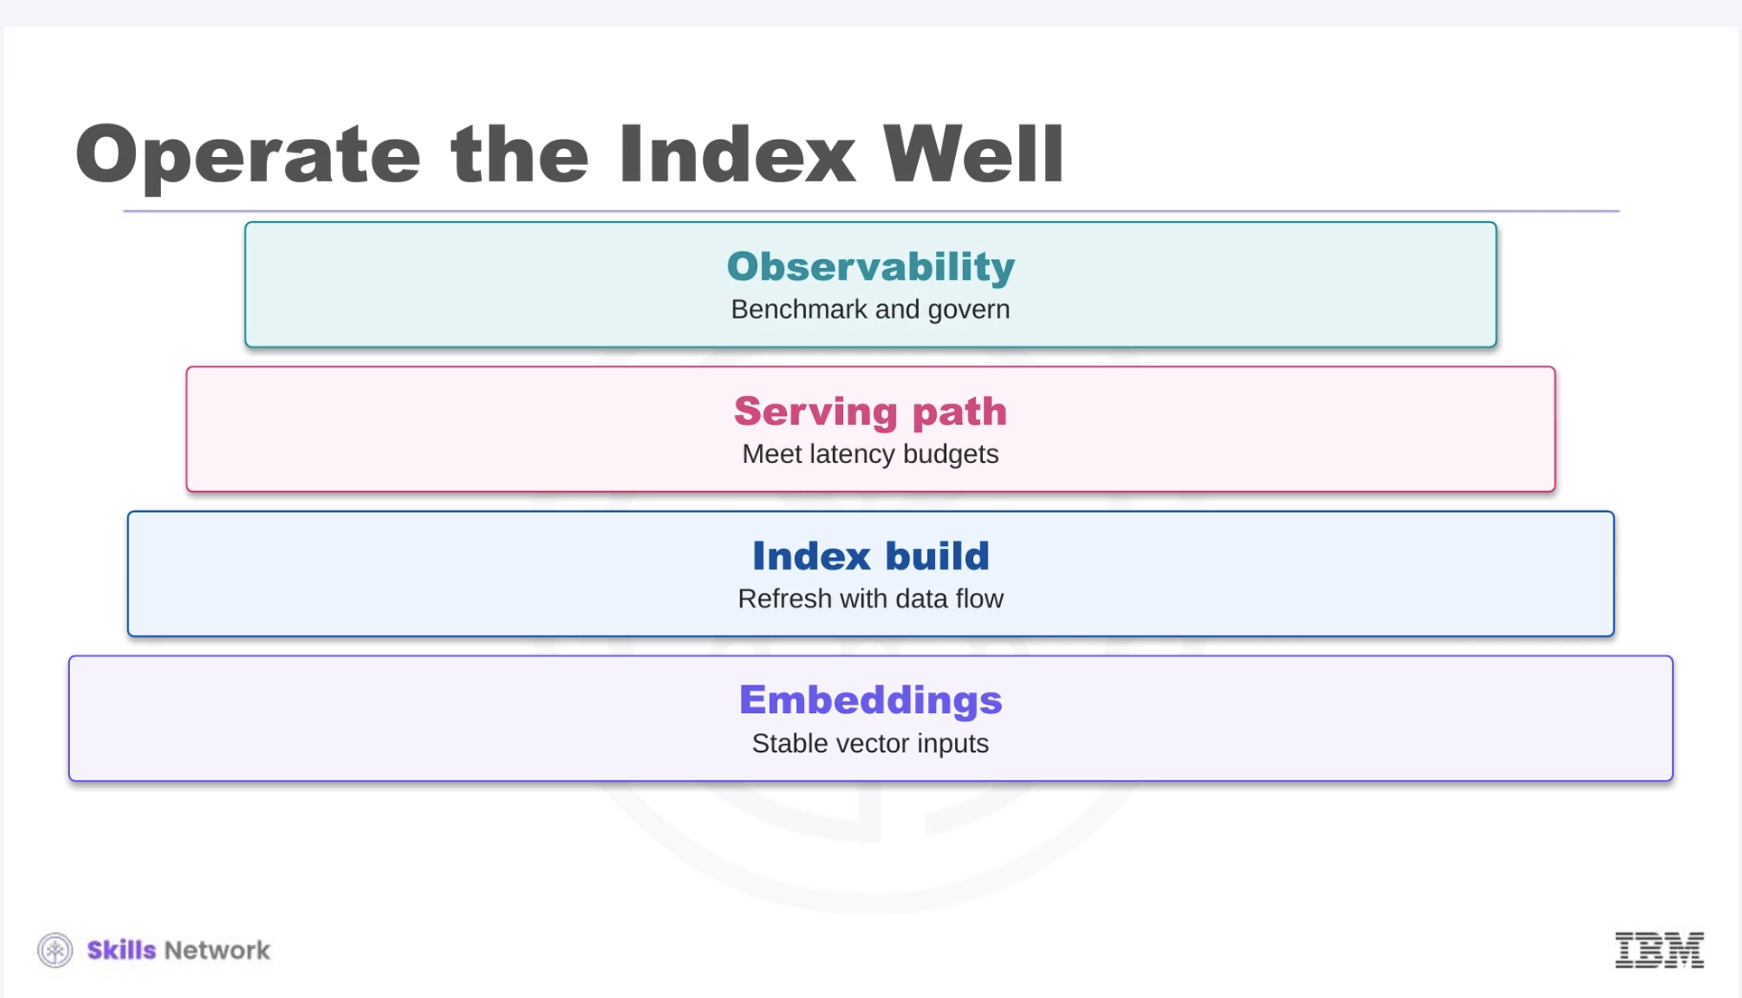
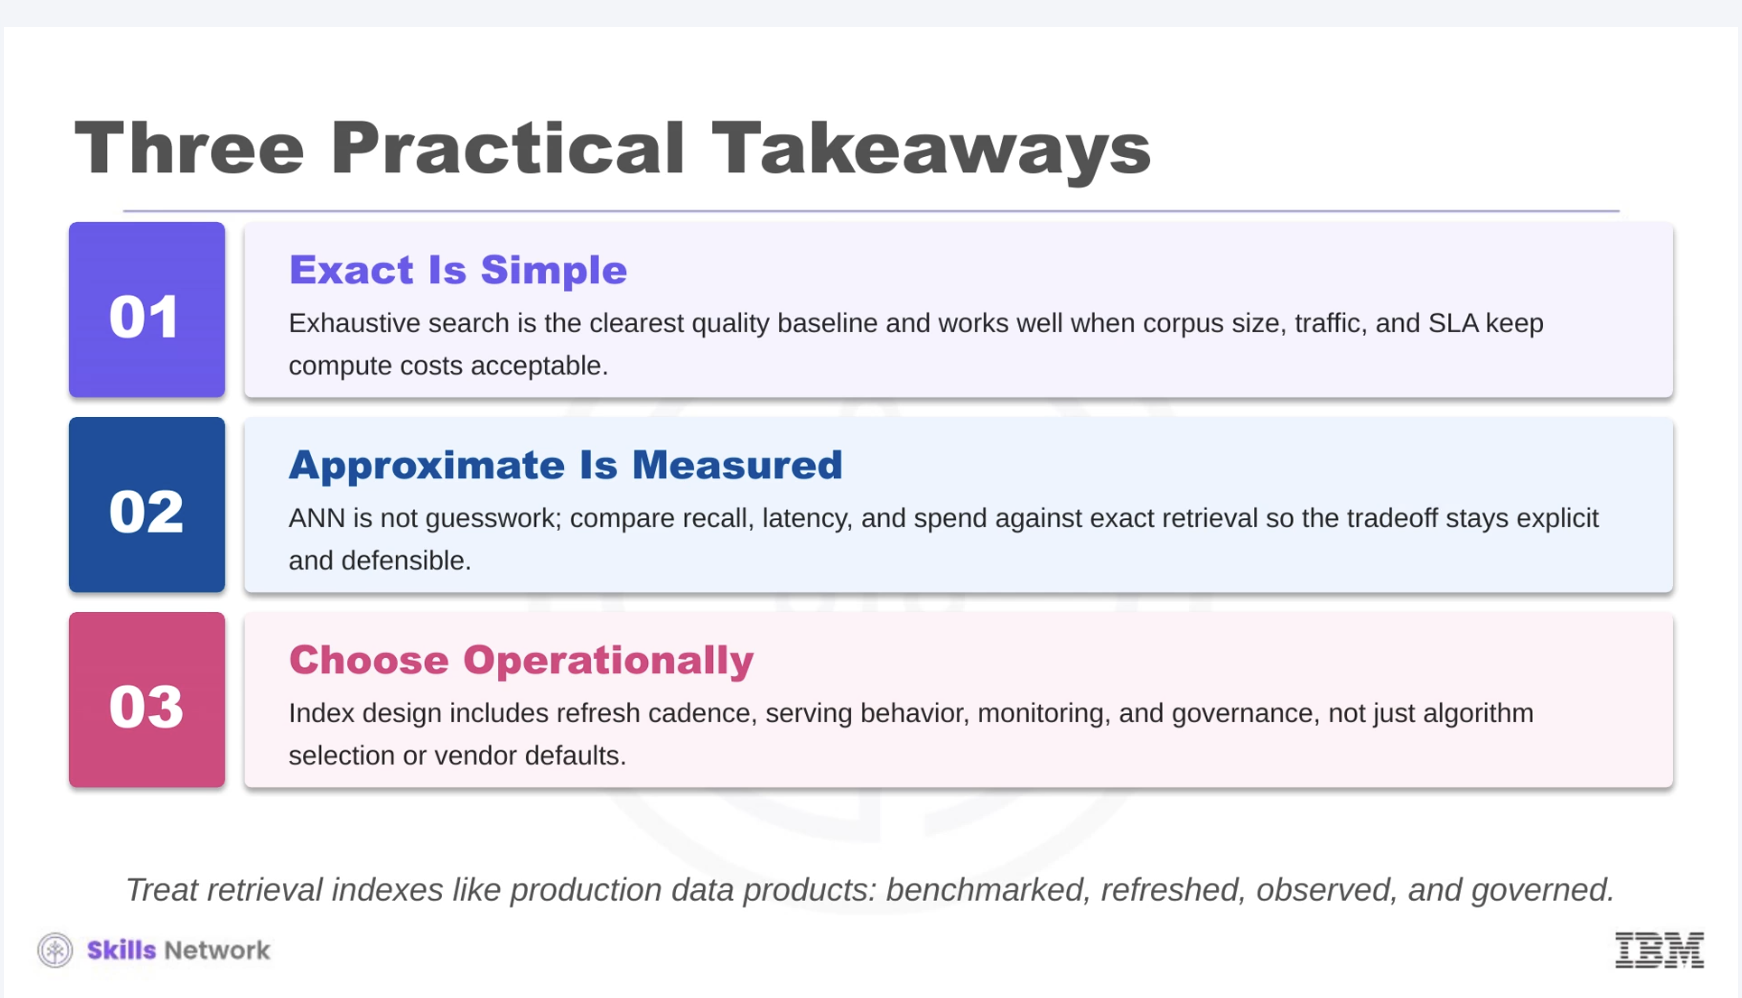



# Practical ```ANN (Approximate nearest neighbour)``` Concepts

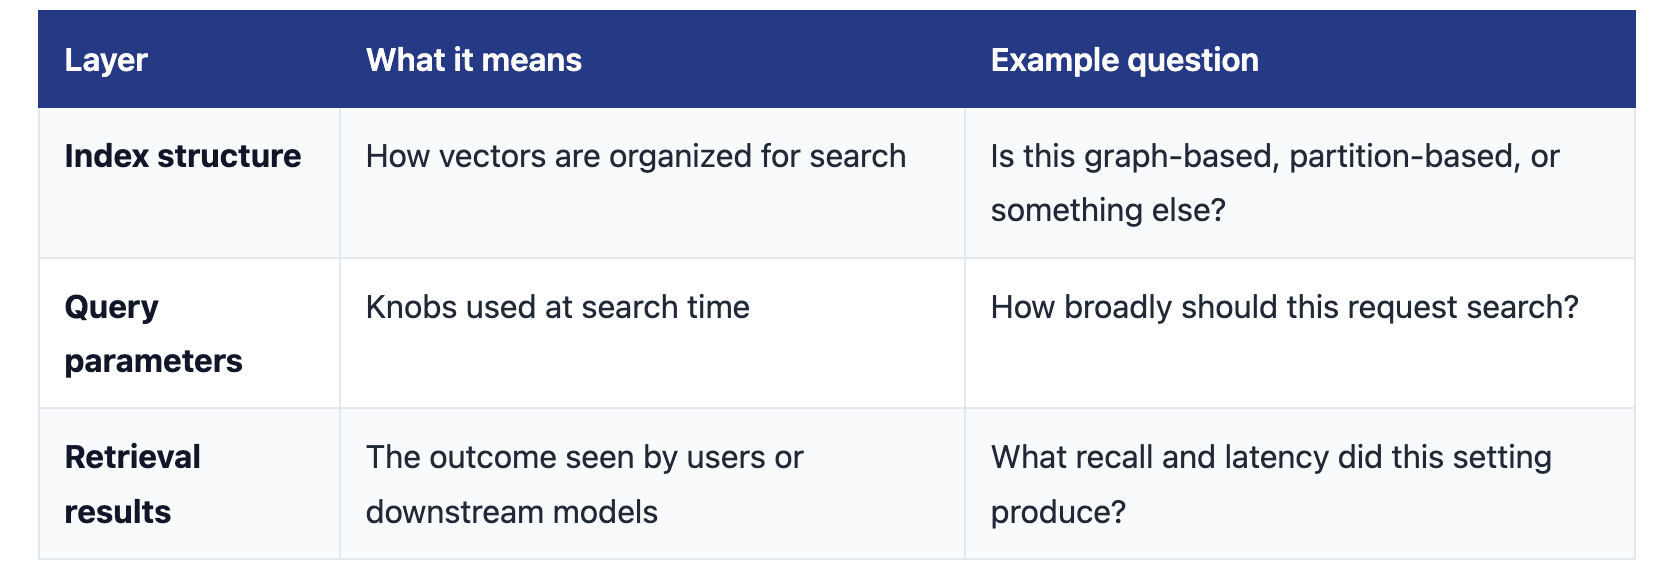
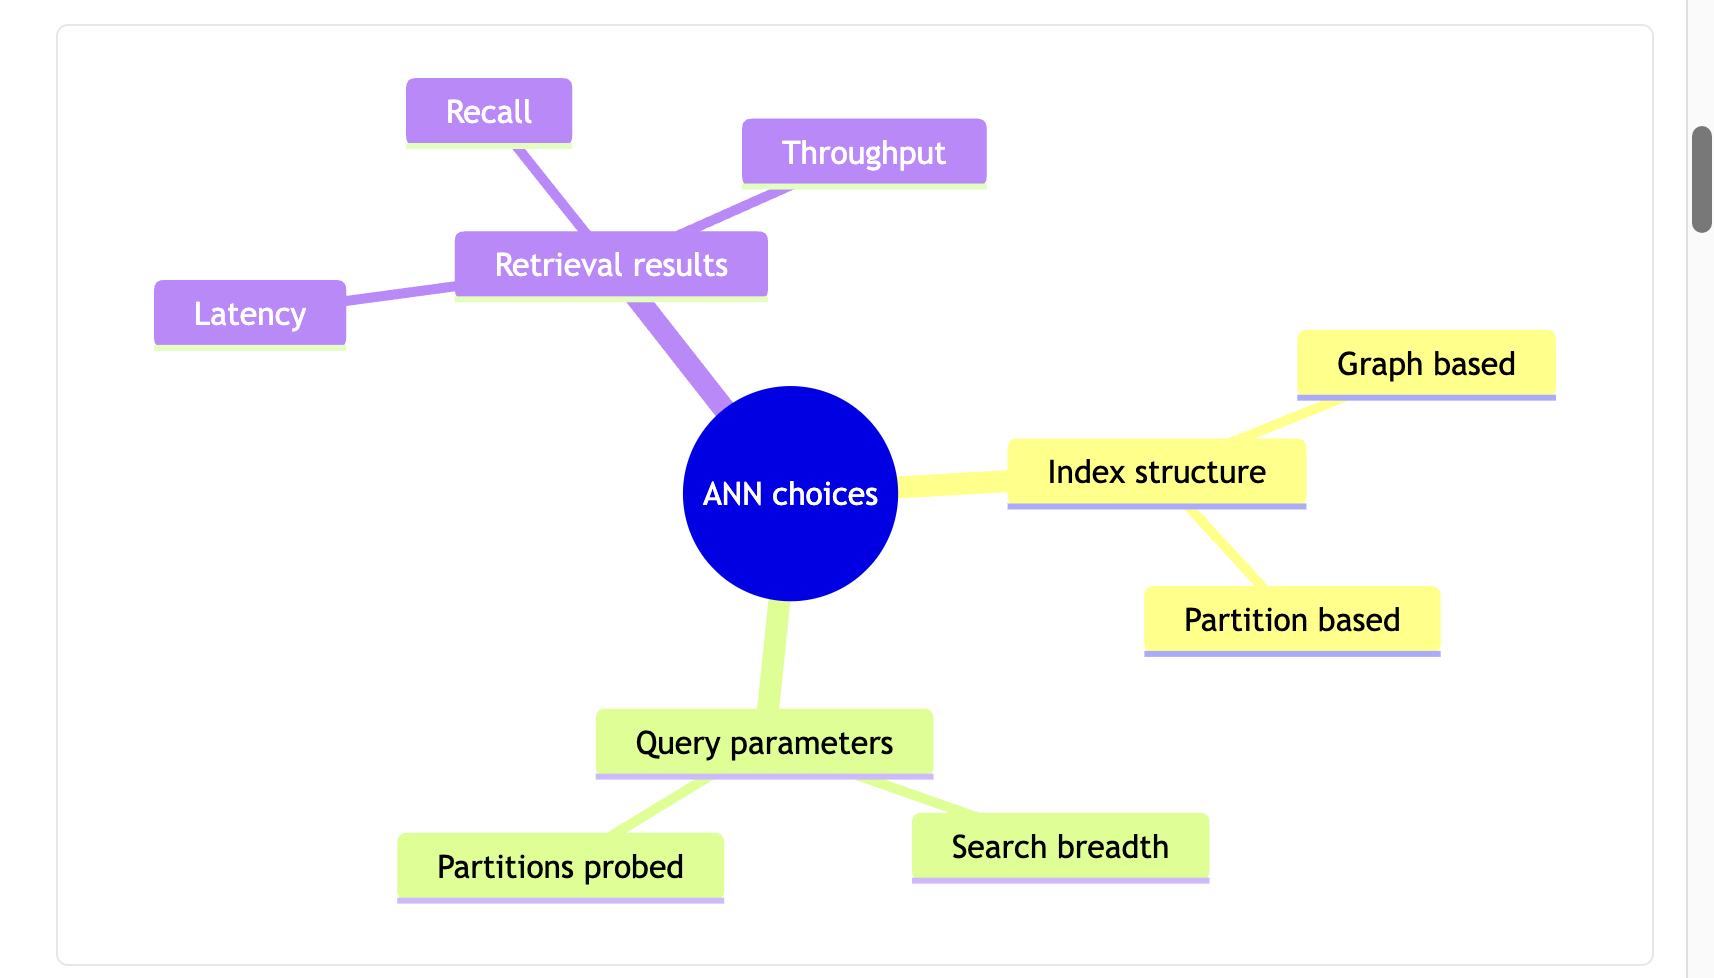


# HNSW (```Hierarchical Navigable Small World```)

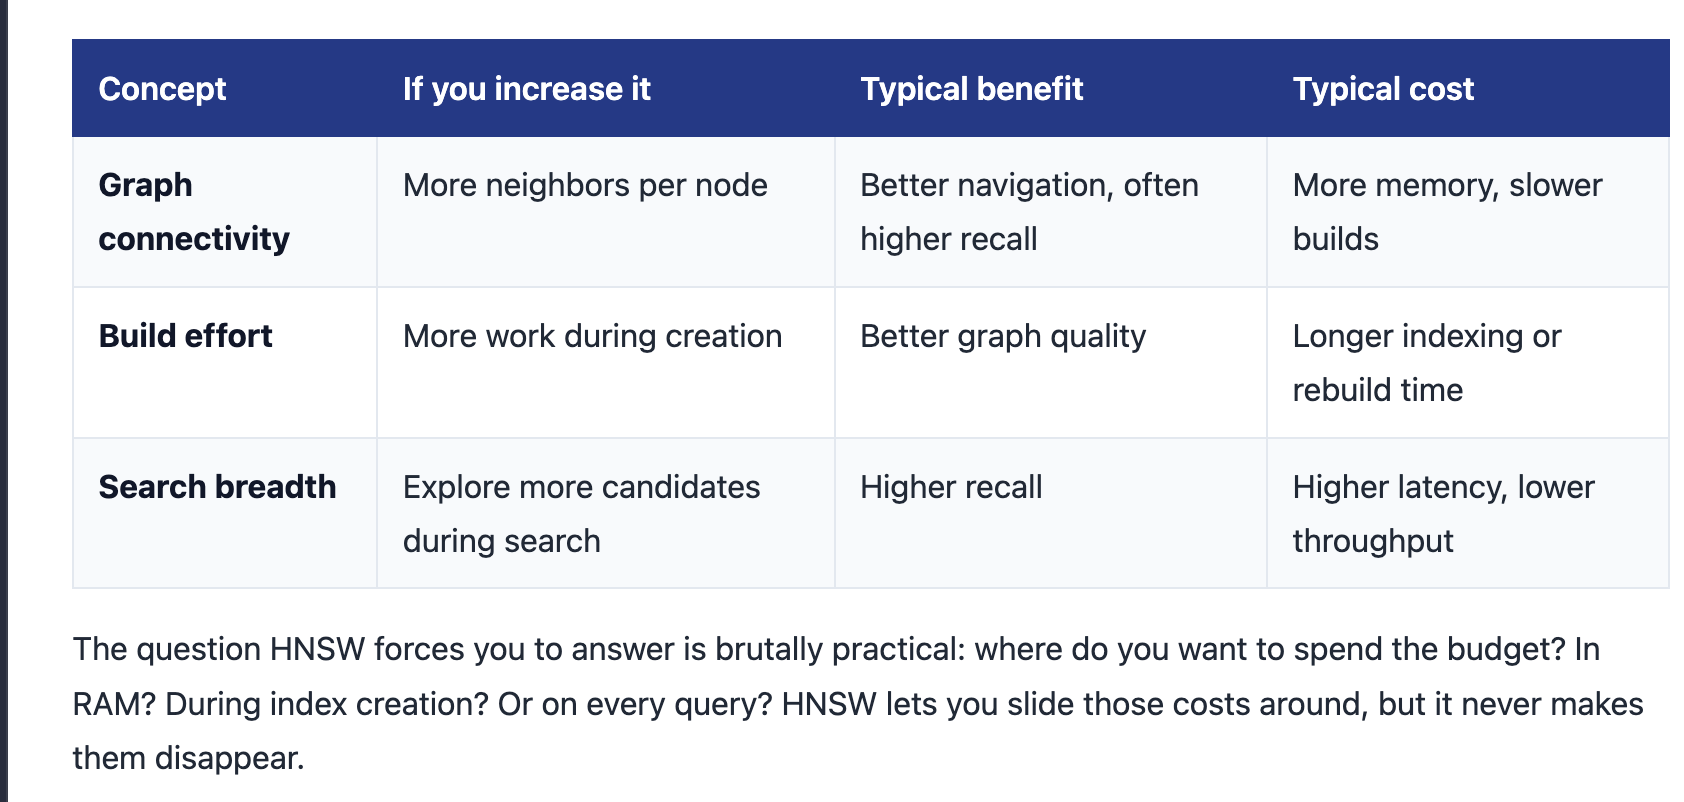
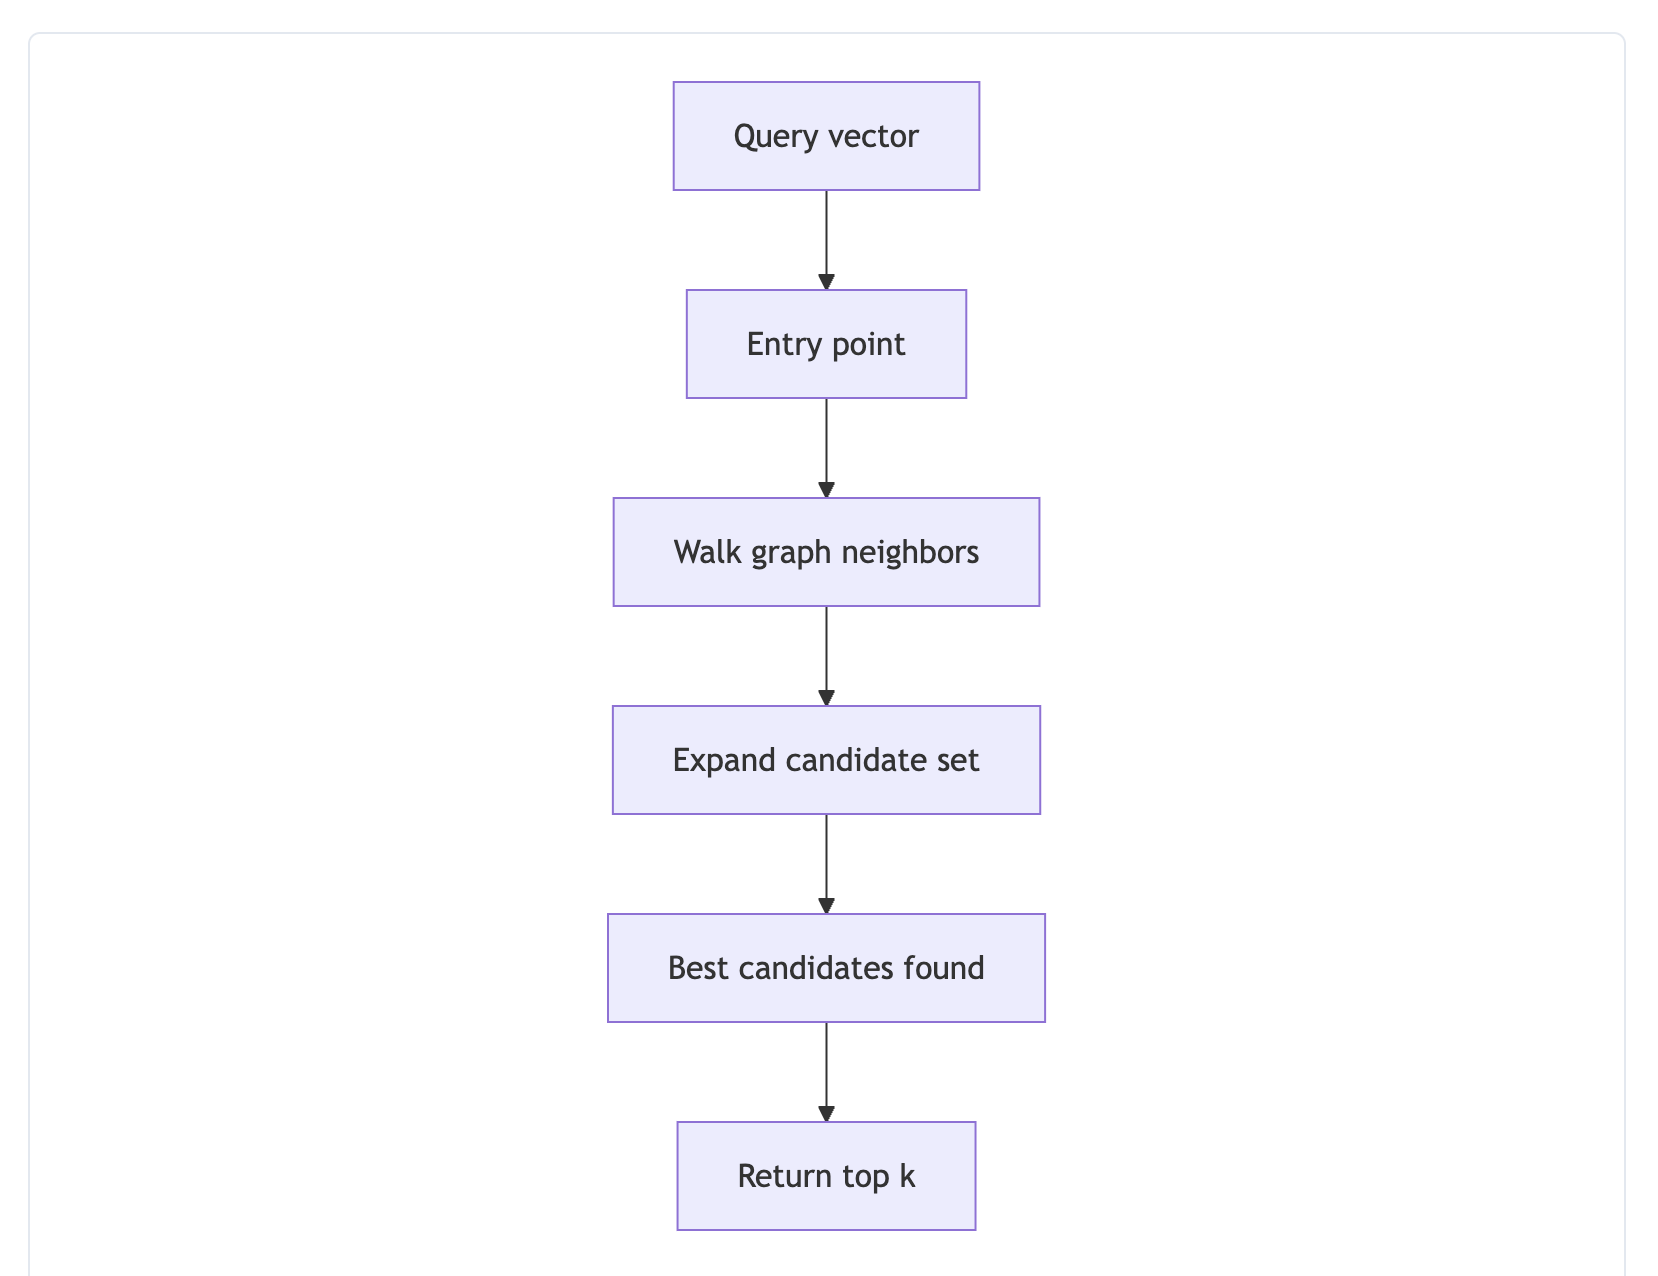


# IVF (```Inverted File Index```)

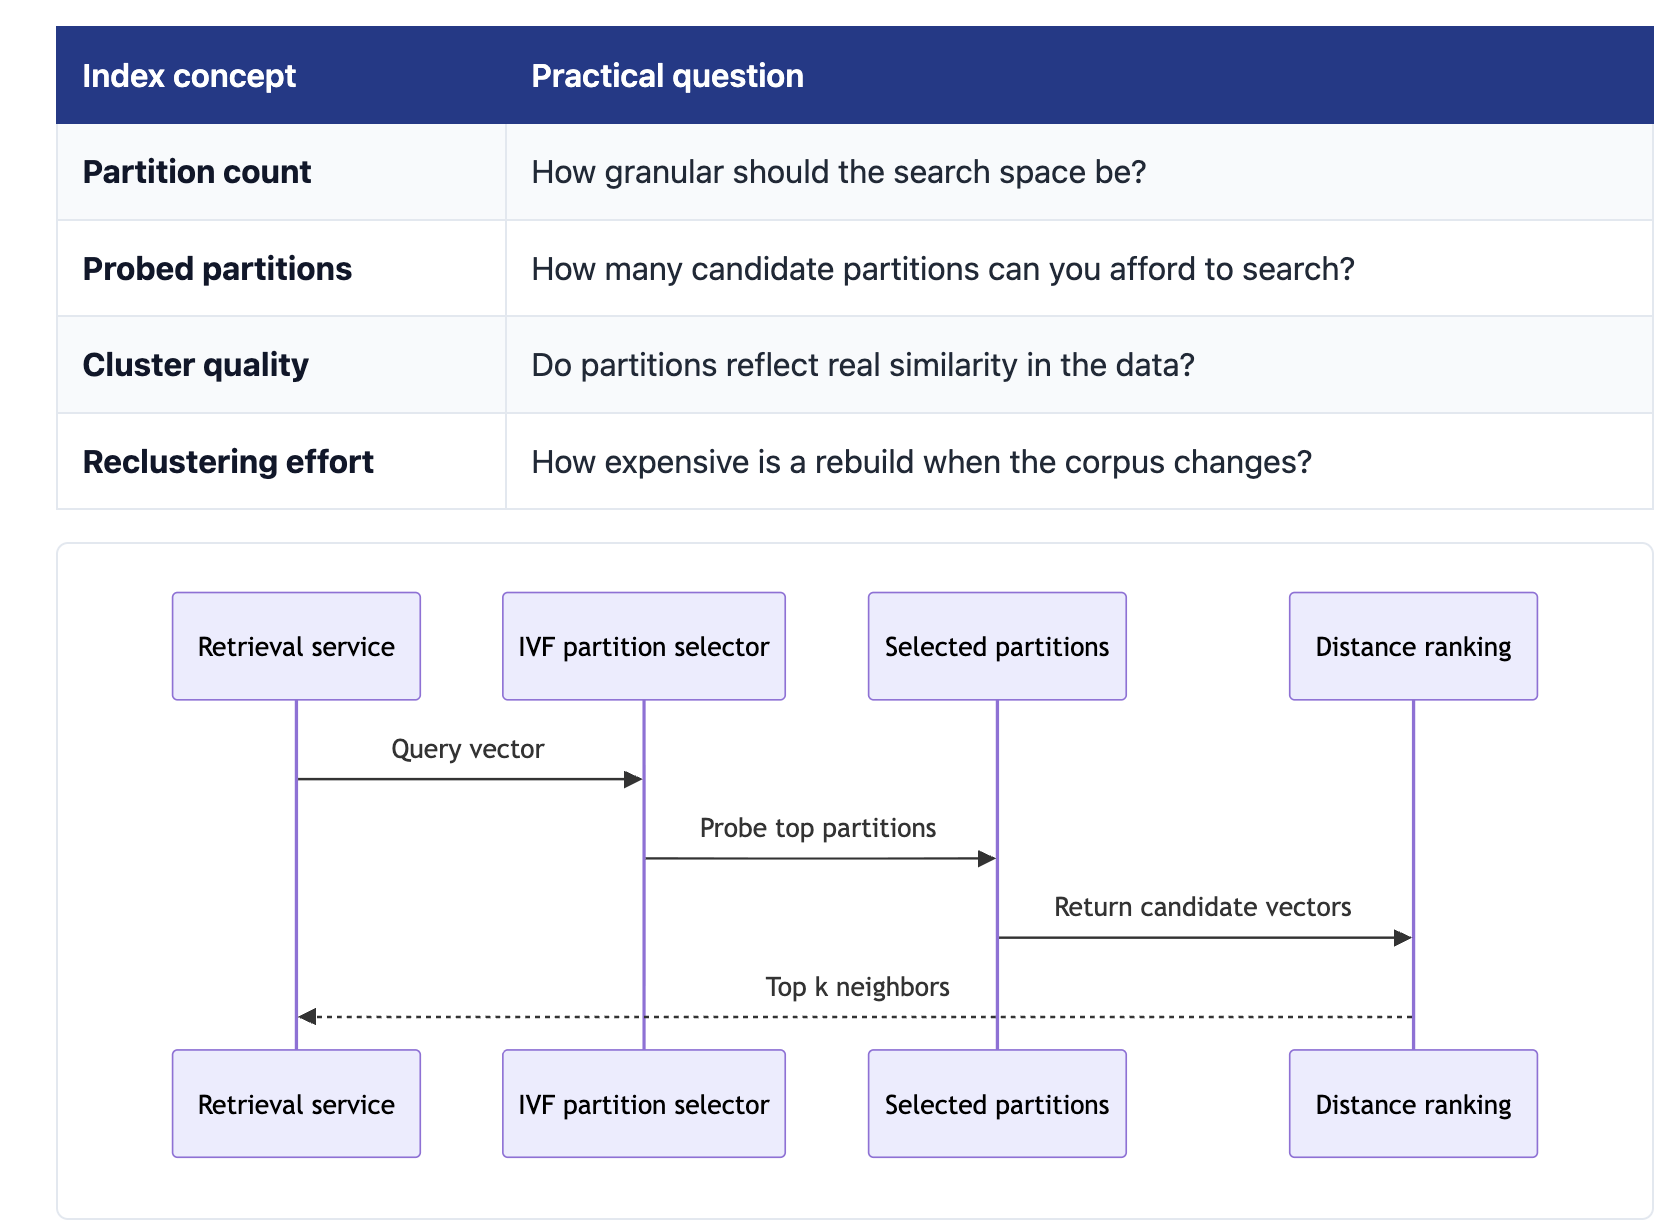


# ANN Search: HNSW, IVF, Benchmarking & Index Health

> 💡 **What this entire section is trying to teach:** the whole chapter boils down to one engineering problem —
> *I have millions of vectors. Searching all of them is expensive. How do I search much faster without destroying retrieval quality?*

That's what **ANN — Approximate Nearest Neighbor** is about.

The course wants me to understand two major ways of doing it:

- **HNSW** → organize vectors as a **graph**
- **IVF** → organize vectors into **partitions/buckets**

Then finally:

- Benchmark them properly
- Understand their recall / latency / memory / build-time tradeoffs
- Understand that an index is a **living production component**, not something you build once and forget.

---

## 1. ANN is about reducing comparisons

Start from the simplest possible case. Suppose I have:

```
10 million vectors
```

A query comes in:

```
"What is the refund policy?"
```

It is converted into:

```
query embedding
```

### Exact search

Compare that query against:

```
vector 1
vector 2
vector 3
...
vector 10,000,000
```

Then calculate distances/similarities and take the top K.

That's **exact nearest-neighbor search**. It gives the true answer, which is why exact search is often used as the **gold standard for evaluation**.

But doing 10 million comparisons for every request is expensive.

### ANN's trick

ANN says:

> *"Why search everything if I can intelligently eliminate most of the vectors?"*

So instead of:

```
10,000,000 vectors
       ↓
compare ALL
       ↓
top K
```

we want:

```
10,000,000 vectors
       ↓
intelligently narrow candidates
       ↓
maybe search 50,000
       ↓
top K
```

That's basically ANN.

> 📌 **Important:** ANN does **not** make distance calculation magically faster.
> It **reduces how many vectors you calculate distance against.**
> That's the core concept of this entire module.

---

## 2. Three things you MUST keep separate

This is one of the most important parts of the chapter. There are three different concepts:

| # | Concept | Question it answers | Examples |
|---|---|---|---|
| 1 | **Index structure** | How are the vectors organized? | HNSW → graph<br>IVF → partitions |
| 2 | **Query-time parameters** | How aggressively do we search that structure? | HNSW → `efSearch`<br>IVF → `nprobe` |
| 3 | **Retrieval results** | What did we actually get? | `Recall@10 = 0.93`<br>`p95 = 41 ms` |

These are **not** the same thing.

For example, if recall suddenly drops, ask:

```
Did the index structure become bad?
```

or:

```
Did I lower efSearch?
```

or:

```
Did my data distribution change?
```

> 💡 The course specifically wants me to develop this **debugging vocabulary**.

---

## 3. HNSW

The first ANN strategy.

**HNSW = Hierarchical Navigable Small World**

Don't worry about memorizing the expansion yet. The practical idea is:

> **HNSW turns your vectors into a graph.**

Imagine:

```
A —— B —— C
|    |    |
D —— E —— F
     |
     G
```

- Each vector is a **node**.
- Nodes have **connections to nearby vectors**.
- Instead of comparing the query against everything, you **navigate through the graph** toward increasingly relevant vectors.

> 💡 The course's mental model:
> **HNSW = navigating a city using connected roads rather than checking every street.**

### HNSW's three important knobs

#### 1. `M`

Think: *How many neighbors/connections does each node maintain?*

Higher `M`:

```
more connections
      ↓
better navigation
      ↓
potentially better recall
```

But:

```
more connections
      ↓
more RAM
      ↓
more build cost
```

So: **`M` = graph connectivity**

#### 2. `efConstruction`

Controls how much effort is spent **building** the graph.

Higher:

```
more work during construction
        ↓
potentially better graph
        ↓
longer build time
```

So: **`efConstruction` = build-time effort**

#### 3. `efSearch`

This is the one encountered most often during tuning. It controls how broadly HNSW searches **during a query**.

Higher:

```
search more candidates
        ↓
recall ↑
        ↓
latency ↑
```

Lower:

```
search fewer candidates
        ↓
latency ↓
        ↓
recall can ↓
```

So: **`efSearch` = query-time search breadth**

### The easiest way to remember HNSW

| Parameter | Think |
|---|---|
| `M` | How connected is my graph? |
| `efConstruction` | How hard did I work to build it? |
| `efSearch` | How hard do I search it? |

And the course's deeper engineering question is:

```
Where do you want to spend your budget?

RAM?
Build time?
Query time?
```

> 📌 You can't eliminate the cost; you can **move it around**.

### Example

Suppose:

```
20 million vectors
```

Conservative HNSW settings give:

```
p95    = 35 ms
recall = 0.88
```

Increase `efSearch`. Now:

```
recall = 0.94
p95    = 80 ms
```

Recall improved. But if the SLA is:

```
p95 < 50 ms
```

| | Before | After raising `efSearch` | SLA |
|---|---|---|---|
| Recall | 0.88 | 0.94 | — |
| p95 | 35 ms ✅ | **80 ms ❌** | < 50 ms |

**→ you just broke production.**

> 💡 **Higher recall isn't automatically better.** You have to satisfy the whole system's constraints.

### Another important HNSW point

The graph isn't magically perfect forever. Imagine you keep inserting vectors:

```
Day 1  → 1M vectors
Day 30 → 5M
Day 90 → 20M
```

The distribution may change. The graph can become less balanced or less navigable.

Therefore:

> 📌 **Rebuilds are part of operating HNSW.**
> An index being "up" doesn't necessarily mean it is still producing optimal retrieval quality.

---

## 4. IVF

Now completely change the mental model.

```
HNSW: Graph navigation
IVF:  Partition the vector space first.
```

**IVF = Inverted File Index**

Imagine:

```
10 million vectors
```

Divide them into groups:

```
Partition 1
Partition 2
Partition 3
...
Partition 1000
```

The vectors are assigned to partitions based on their **location in vector space**.

Then a query arrives. Instead of searching all 1000 partitions:

```
Query
 ↓
Identify promising partitions
 ↓
Search only those
 ↓
Top K
```

That's IVF.

### IVF has two key parameters

#### `nlist`

Think: *How many partitions/buckets do I create?*

Example:

```
nlist = 100
```

means roughly **100 partitions** (conceptually).

#### `nprobe`

This is the **query-time** knob.

Think: *How many partitions should I actually search for this query?*

Suppose:

```
nlist  = 100
nprobe = 5
```

There are 100 partitions, but for this query only the **5 most promising** ones are searched.

### And again, the tradeoff

Increase `nprobe`:

```
more partitions searched
       ↓
more candidates
       ↓
recall ↑
       ↓
latency ↑
```

Decrease `nprobe`:

```
fewer partitions
       ↓
fewer comparisons
       ↓
latency ↓
       ↓
recall can ↓
```

> 📌 **`nprobe` is IVF's query-time search-breadth knob.**
> One of the things to absolutely remember for the quiz/lab.

### ⚠️ But IVF has a special problem

What if the partitions are bad?

Imagine semantically similar vectors are scattered:

```
"refund policy"
        ↓
Partition 2
Partition 17
Partition 41
Partition 89
```

But the query only probes:

```
Partition 2
Partition 17
```

You miss the vectors in 41 and 89.

- Nothing crashed.
- The system is fast.
- But recall went down.

> 💡 That's why the course says: **IVF can be fast at missing things.**
> The quality of the partitioning/clustering matters enormously.

### IVF's operational problem

Partitions are **learned from your data**.

Suppose initially the corpus looks like:

```
English policies
technical documents
support tickets
```

Then six months later:

```
new languages
new products
different embedding model
massive new category
```

The old partitioning may no longer represent the actual vector distribution. That's called **drift**.

So IVF may require:

```
reclustering / rebuilding
```

as the data distribution changes.

---

## 5. HNSW vs IVF

Side by side:

| | HNSW | IVF |
|---|---|---|
| Basic idea | Graph | Partitions |
| Search | Navigate graph | Search selected partitions |
| Main query knob | `efSearch` | `nprobe` |
| Build knobs | `M`, `efConstruction` | `nlist` / clustering |
| Main strength | Strong recall/latency behavior | Clear control over search scope |
| Main cost | Memory/build effort | Partition quality/rebuild complexity |
| Main risk | Graph degradation/update churn | Bad or stale partitions |

Don't memorize the table blindly. Remember the mental models:

```
HNSW = roads
IVF  = neighborhoods
```

---

## 6. Benchmarking

Now the course gets **VERY** important.

Never say:

> ❌ *"HNSW is faster, therefore HNSW wins."*

That's bad engineering. You need to measure several things.

### 1. Recall

How many of the true nearest neighbors did we recover?

Example:

```
True: A B C D E F G H I J
ANN:  A B C D X Y Z P Q R

Recovered: A B C D
```

So:

```
Recall@10 = 4/10 = 0.4
```

### 2. p50

The 50th percentile. Roughly: **half of requests are faster than this number.**
Useful for understanding *typical* performance.

### 3. p95

**95% of requests are at or below this latency.**

This is much more important for production SLAs than simply saying *"Average latency = 20 ms."*

You might have:

```
average = 20 ms
p95     = 90 ms
p99     = 250 ms
```

That can be a terrible user experience if the SLA is 50 ms.

### 4. Throughput

How many queries can the system handle? For example:

```
5,000 queries/sec
```

A configuration that gives amazing recall but drops throughput massively may not work under real traffic.

### 5. Memory

Especially important for HNSW. You might get:

```
Recall  = 0.98
Latency = 20 ms
```

but require:

```
200 GB RAM
```

That may be unacceptable.

### 6. Build time

How long does it take to create/rebuild the index? Example:

```
Index A → 10 minutes
Index B → 6 hours
```

If the data changes constantly, that matters.

### Summary of what to measure

| Metric | Answers the question… |
|---|---|
| Recall | How many true nearest neighbors did we recover? |
| p50 | What is typical latency? |
| p95 | What latency do 95% of requests stay under? (SLA) |
| Throughput | How many queries/sec can we handle? |
| Memory | How much RAM does the index need? |
| Build time | How long to create/rebuild the index? |

### The course's example

```
Dataset:        10M support articles
Model:          text-embedding-3-large
Index:          HNSW

M              = 32
efConstruction = 200
efSearch       = 96

Recall@10  = 0.93
p50        = 18 ms
p95        = 41 ms
Memory     = 28 GB
Build time = 2h 14m
```

Notice something important. They don't just record:

```
"Recall = 0.93"
```

They record the **parameters that produced it** — because otherwise you can't reproduce the result.

The benchmark becomes: *"Trust me bro, it was fast."* 😂

> 📌 The course explicitly warns against this.

### Production evaluation

The course recommends roughly this workflow:

```
Production-like embeddings
        ↓
Realistic queries
        ↓
Exact search as reference
        ↓
ANN configuration
        ↓
Measure:
   Recall
   p50
   p95
   Throughput
   Memory
   Build time
        ↓
Decision
```

And keep a **decision log**:

- What did we optimize?
- What did we sacrifice?

That's proper retrieval engineering.

---

## 7. One final concept: Index health

Subtle and very important.

You build your index. It works. Then months pass:

```
new documents
deletes
updates
new embeddings
data distribution changes
```

The index can still respond successfully:

```
HTTP 200 ✅
```

But its retrieval quality may slowly deteriorate. That's **index drift / degradation**.

So production ANN needs:

```
Build
 ↓
Serve
 ↓
Monitor
 ↓
Detect drift
 ↓
Rebuild / recluster
 ↓
Serve again
```

The course specifically emphasizes having:

- rebuild strategy
- insert/delete handling
- RAM headroom
- recall/golden-set monitoring
- IVF partition monitoring
- HNSW update-health checks

---

## 🧠 The entire section in one picture

```
                 MILLIONS OF VECTORS
                         │
                         ▼
                Exact Search
              "Check everything"
                         │
                  Accurate but
                     expensive
                         │
                         ▼
                      ANN
             "Check intelligently"
                    /       \
                   /         \
                  ▼           ▼
               HNSW          IVF
               Graph       Partitions
                 │             │
                 │             │
              efSearch       nprobe
                 │             │
                 ▼             ▼
           Search breadth  Partitions searched
                 │             │
                 └──────┬──────┘
                        ▼
                 Recall / Latency
                        │
                        ▼
          ┌───────────────────────────┐
          │ Benchmark the whole thing │
          ├───────────────────────────┤
          │ Recall                    │
          │ p50 / p95 / p99           │
          │ Throughput                │
          │ Memory                    │
          │ Build time                │
          └───────────────────────────┘
```

---

## 8. What I actually need to know

For my level, don't spend time learning how to implement HNSW or IVF from scratch. I need to be able to see:

### ANN

- **Why?** → Reduce comparisons.

### HNSW

| Question | Answer |
|---|---|
| What? | Graph-based |
| `M`? | Number of graph connections |
| `efConstruction`? | Build effort |
| `efSearch`? | Query search breadth |

### IVF

| Question | Answer |
|---|---|
| What? | Partition-based |
| `nlist`? | Number of partitions |
| `nprobe`? | Number of partitions searched per query |

### Tradeoff

```
Search more → recall ↑ → latency ↑
Search less → latency ↓ → recall can ↓
```

### Evaluation

Don't look only at speed:

- Recall
- Latency
- Throughput
- Memory
- Build time

### Production

Indexes can drift:

```
updates → drift → rebuild/recluster
```

> 📌 **That is the whole section.**

 - # **```CHOOSING an ANN INDEX```**

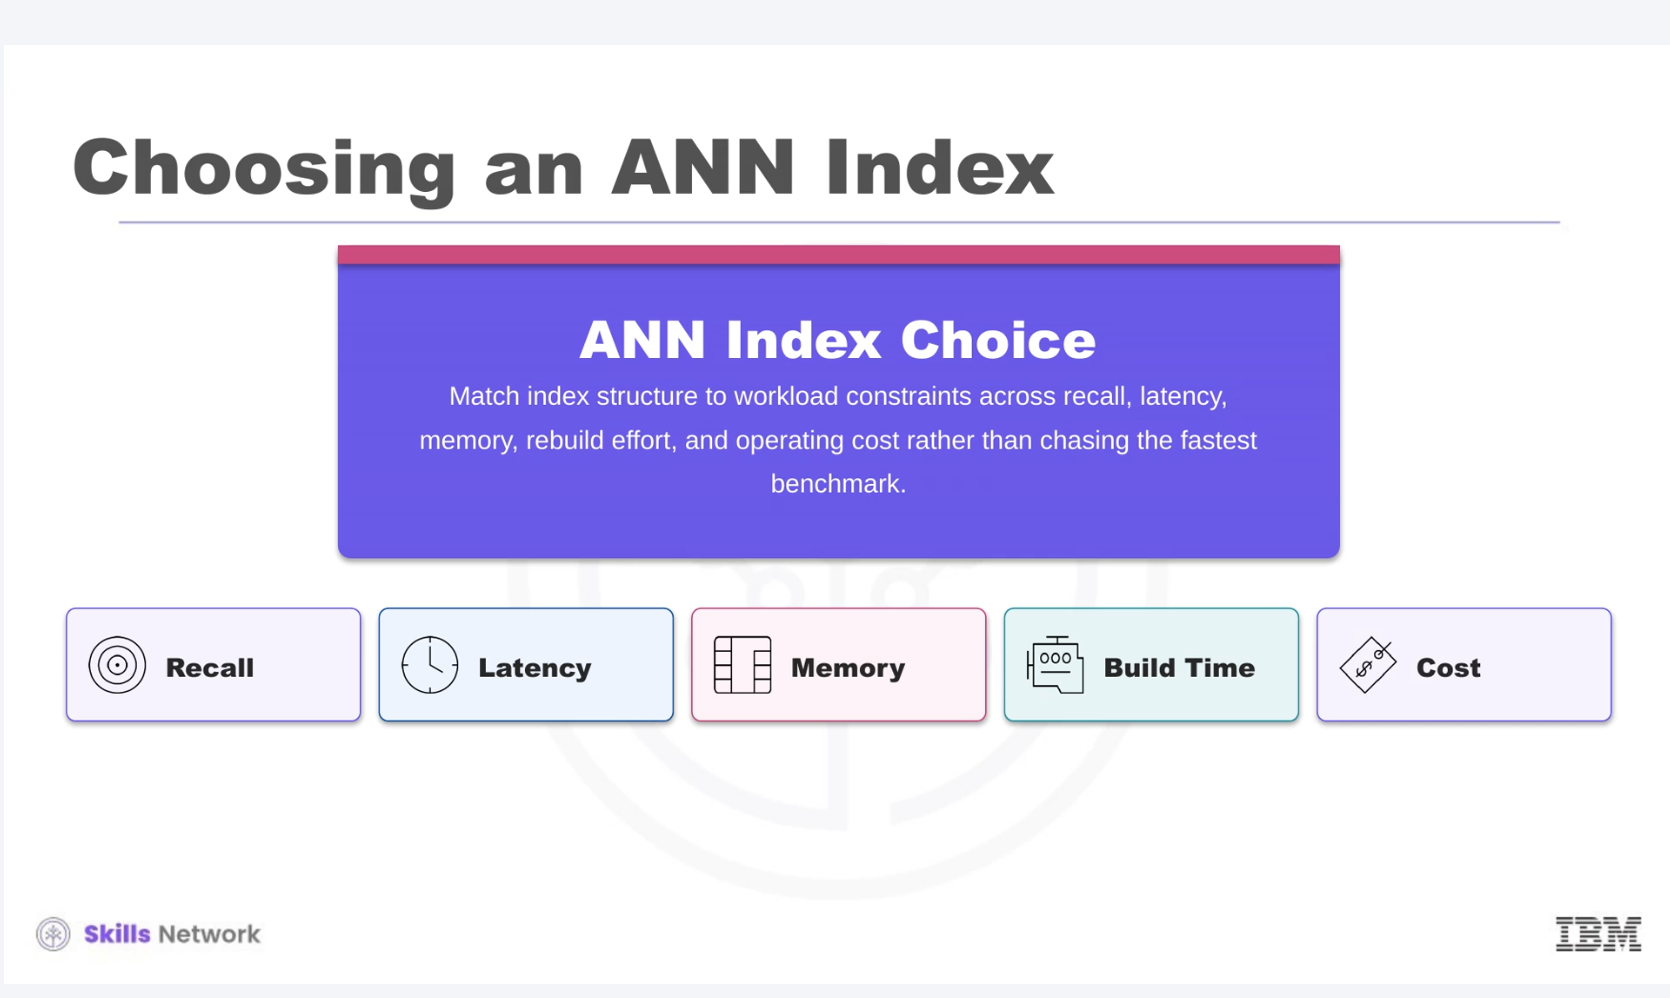
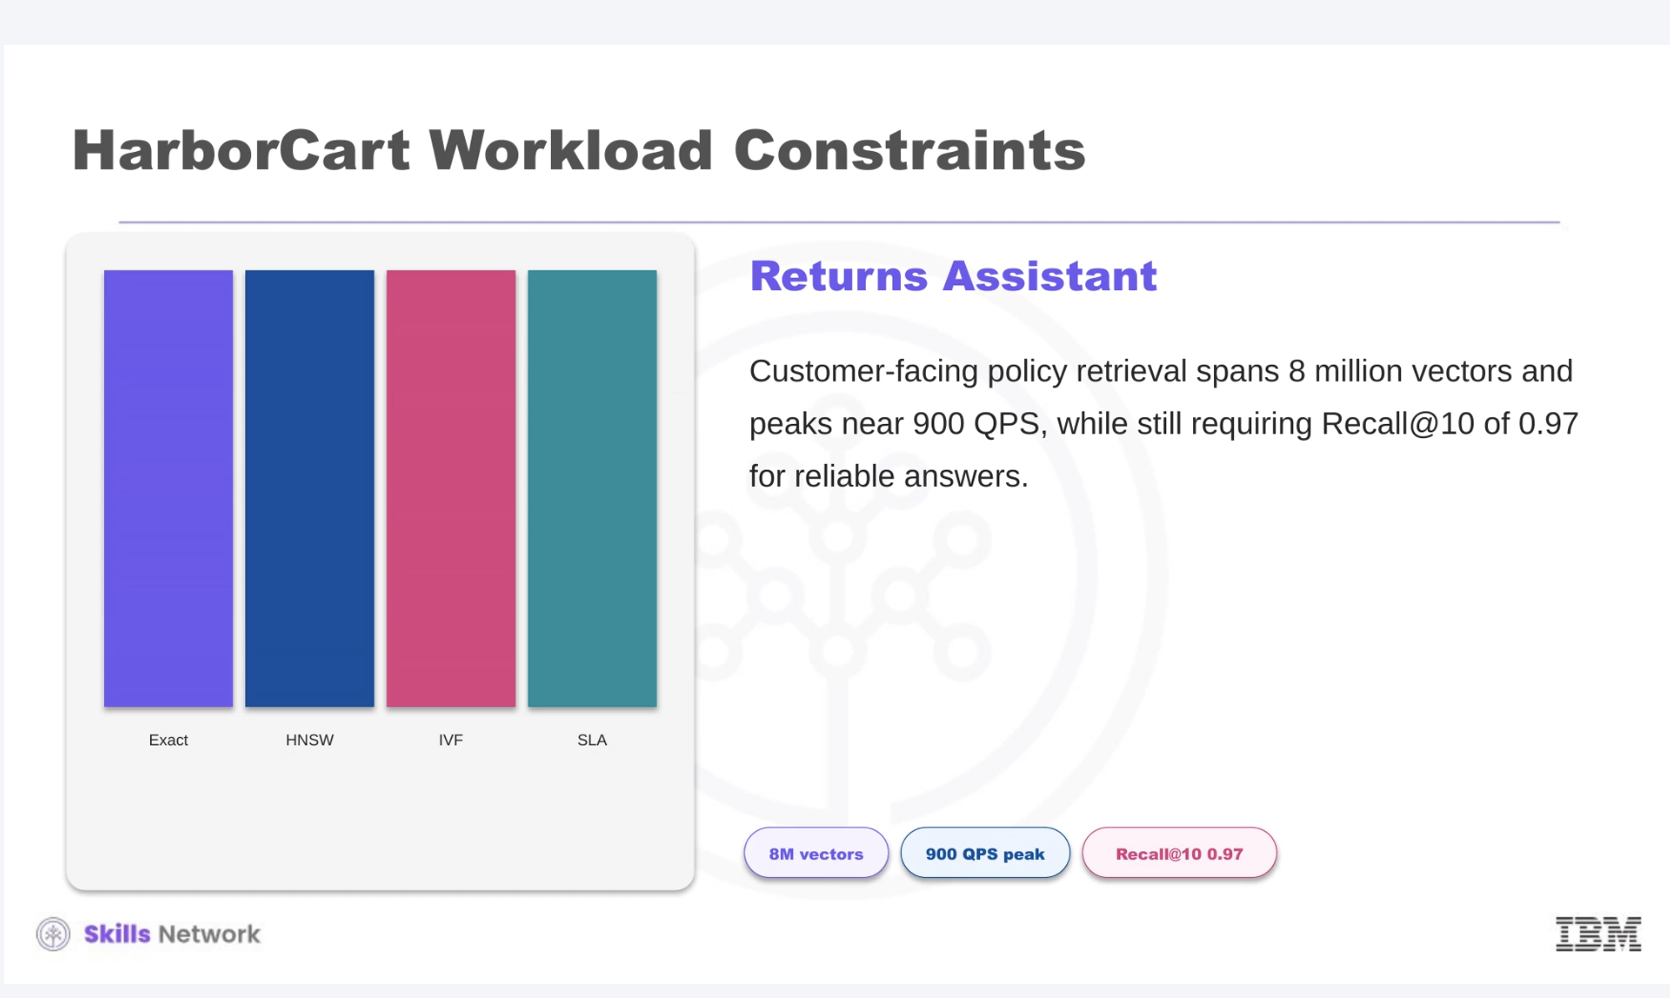
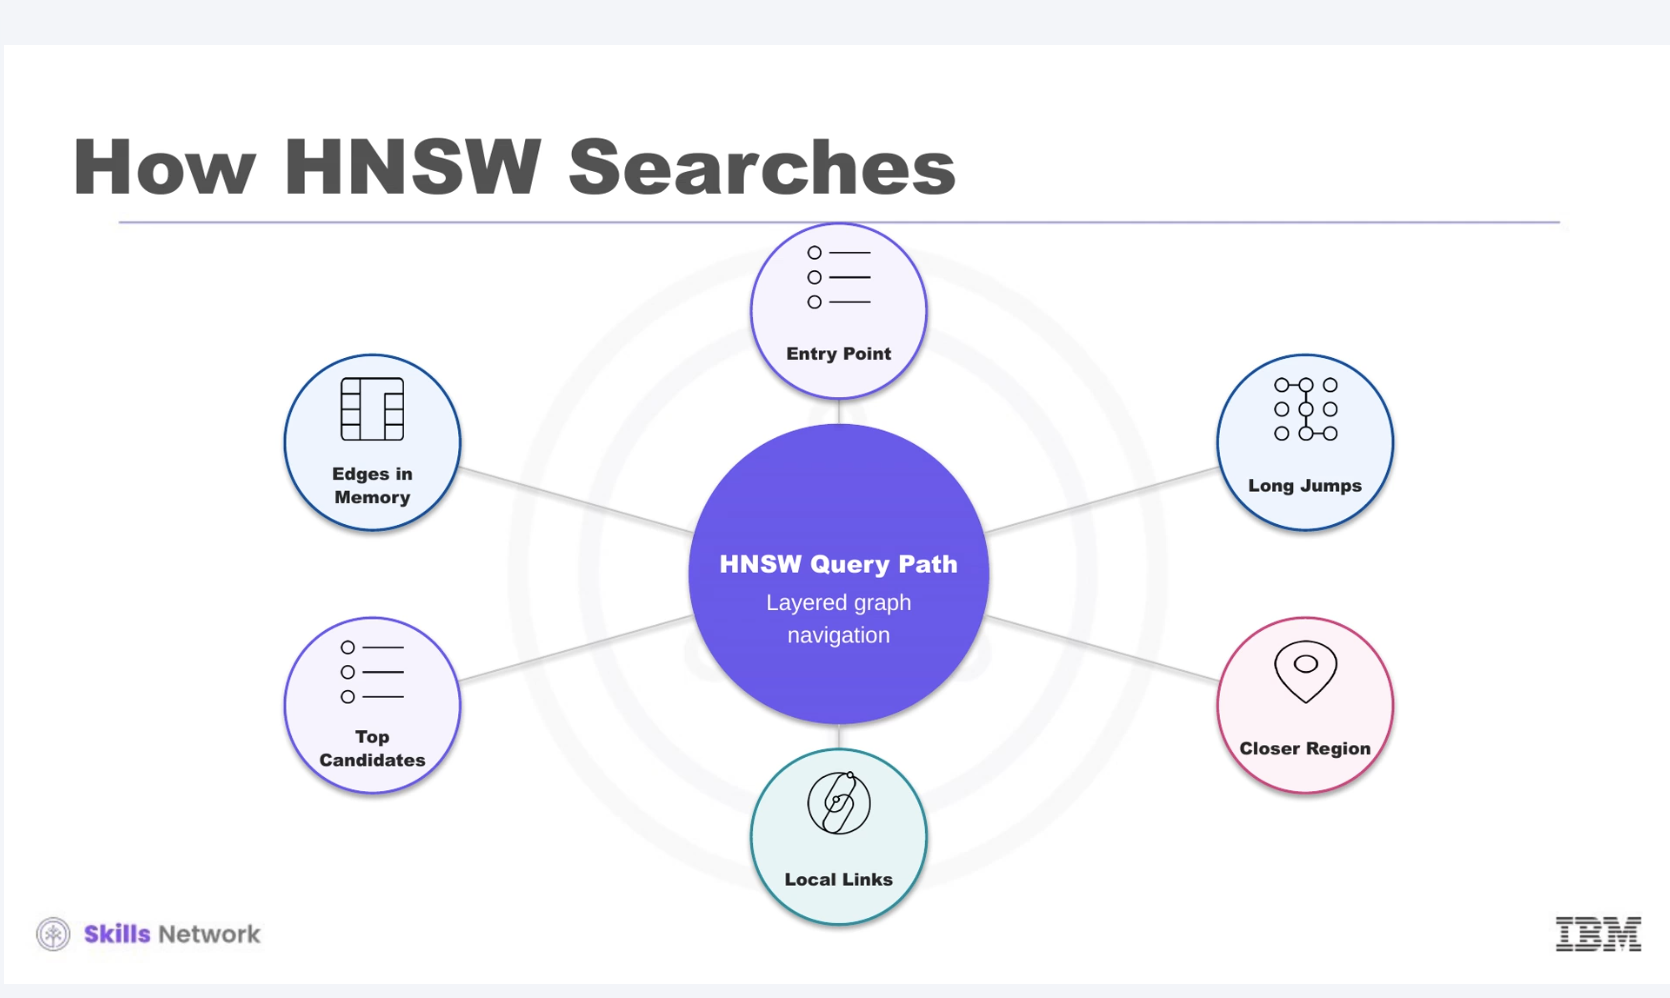
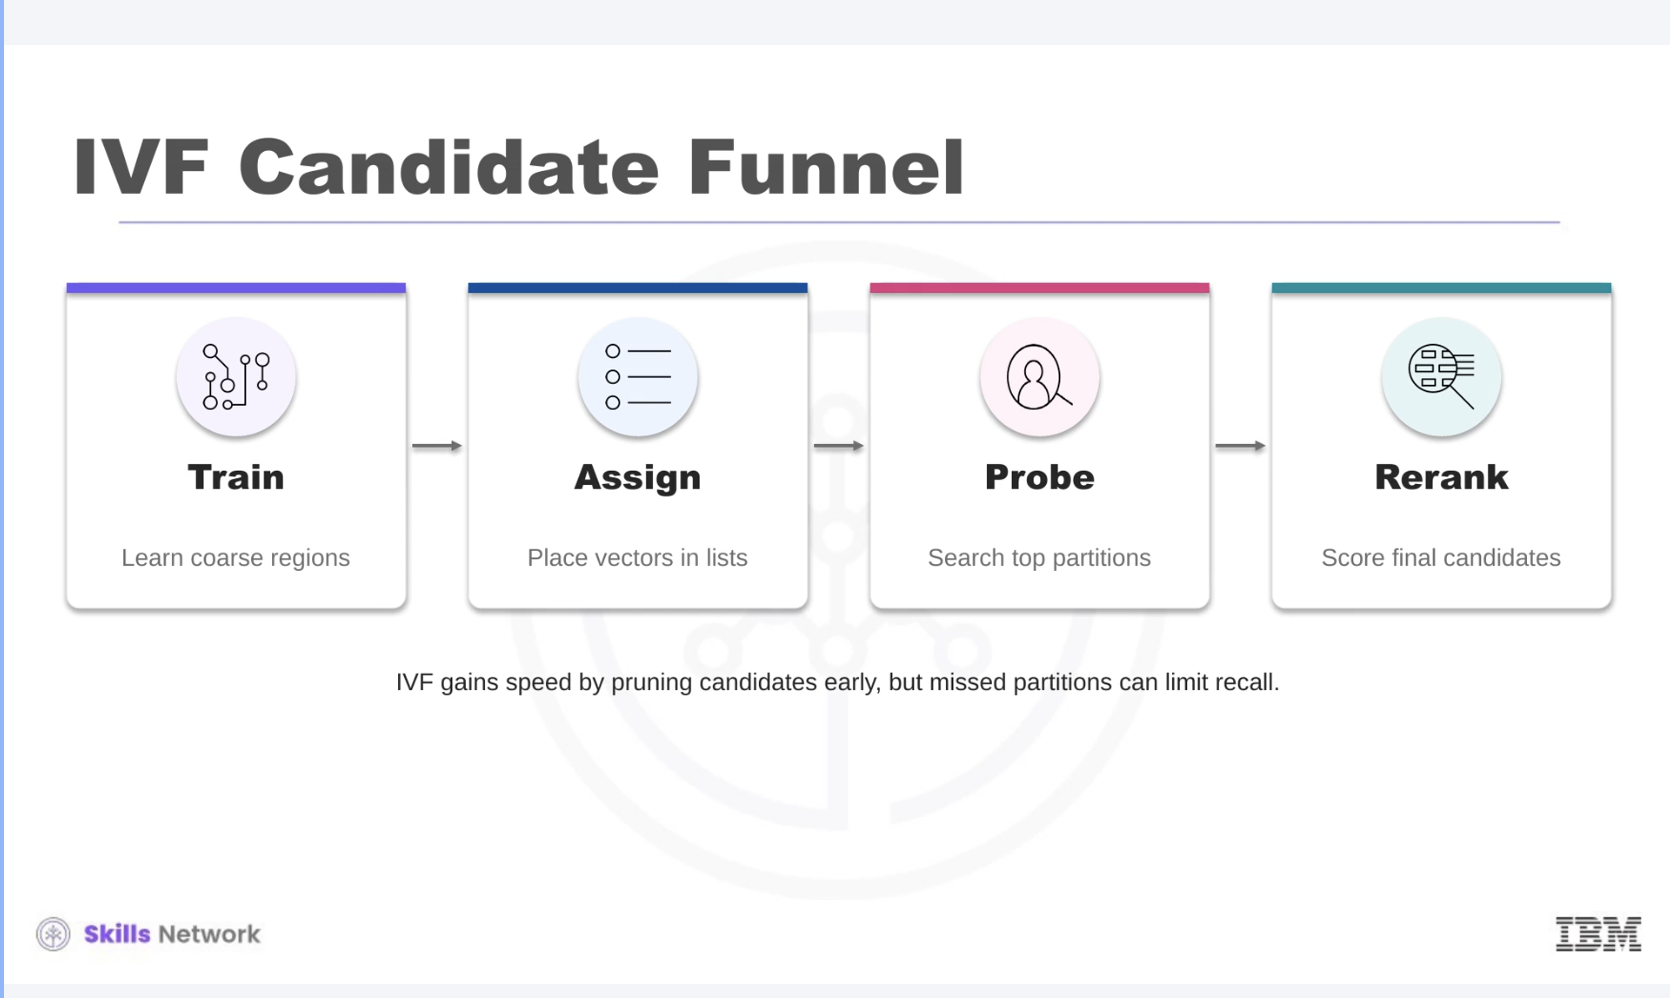
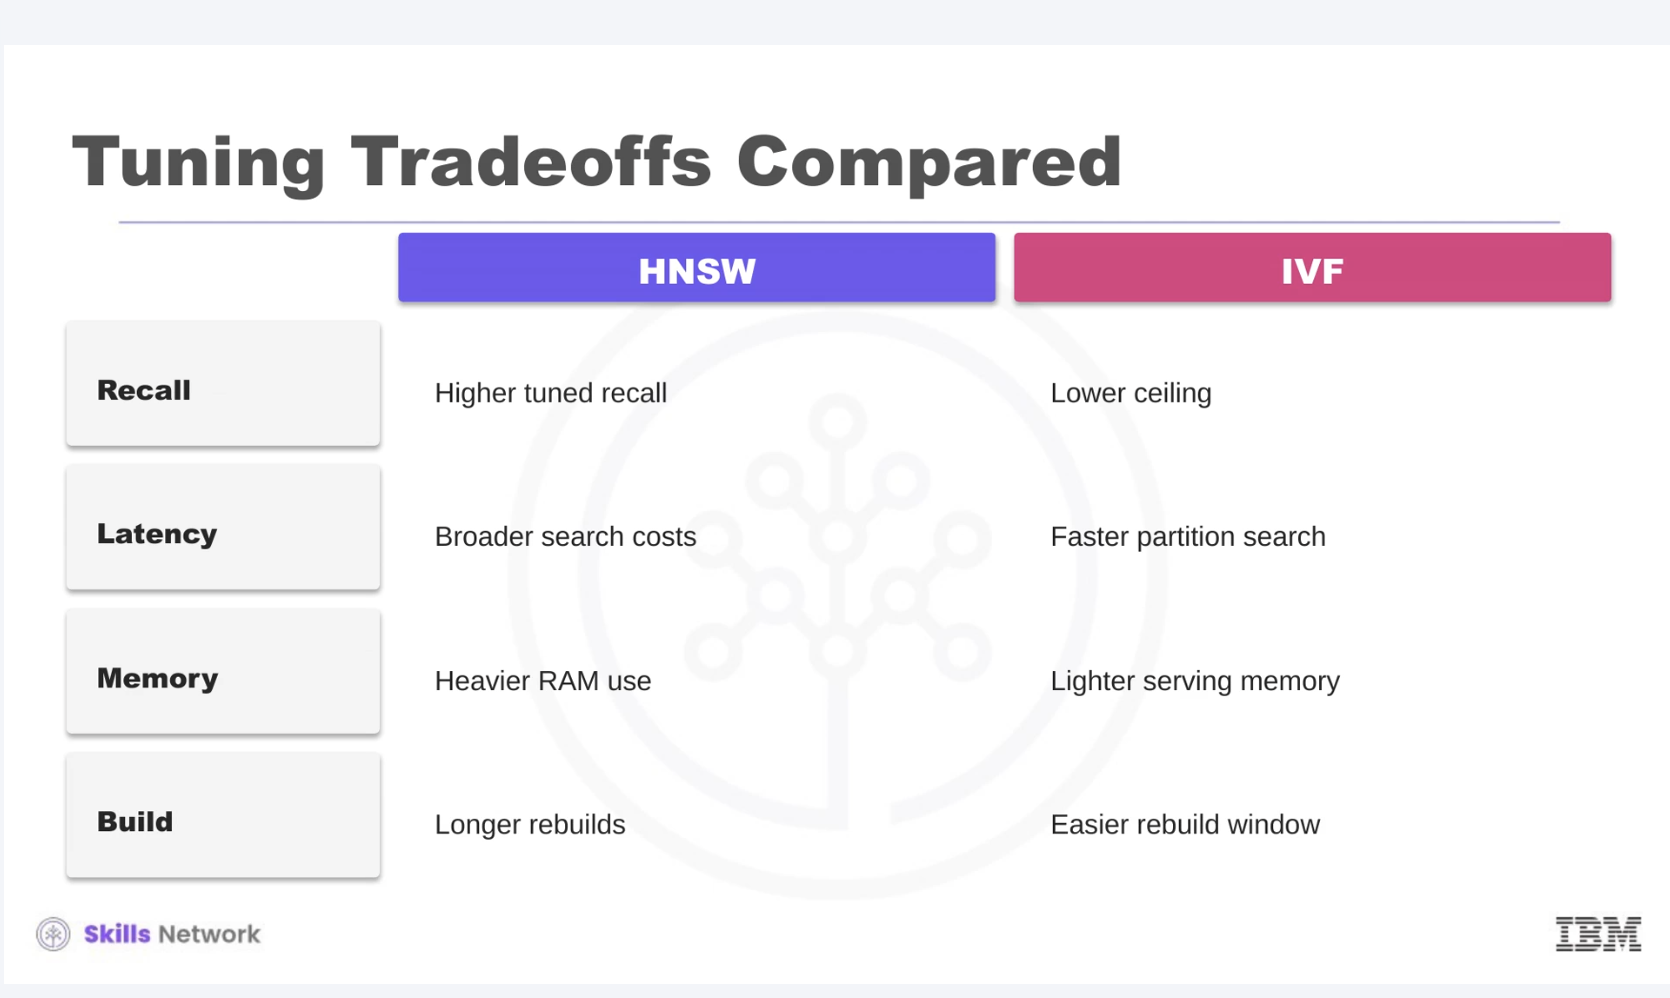
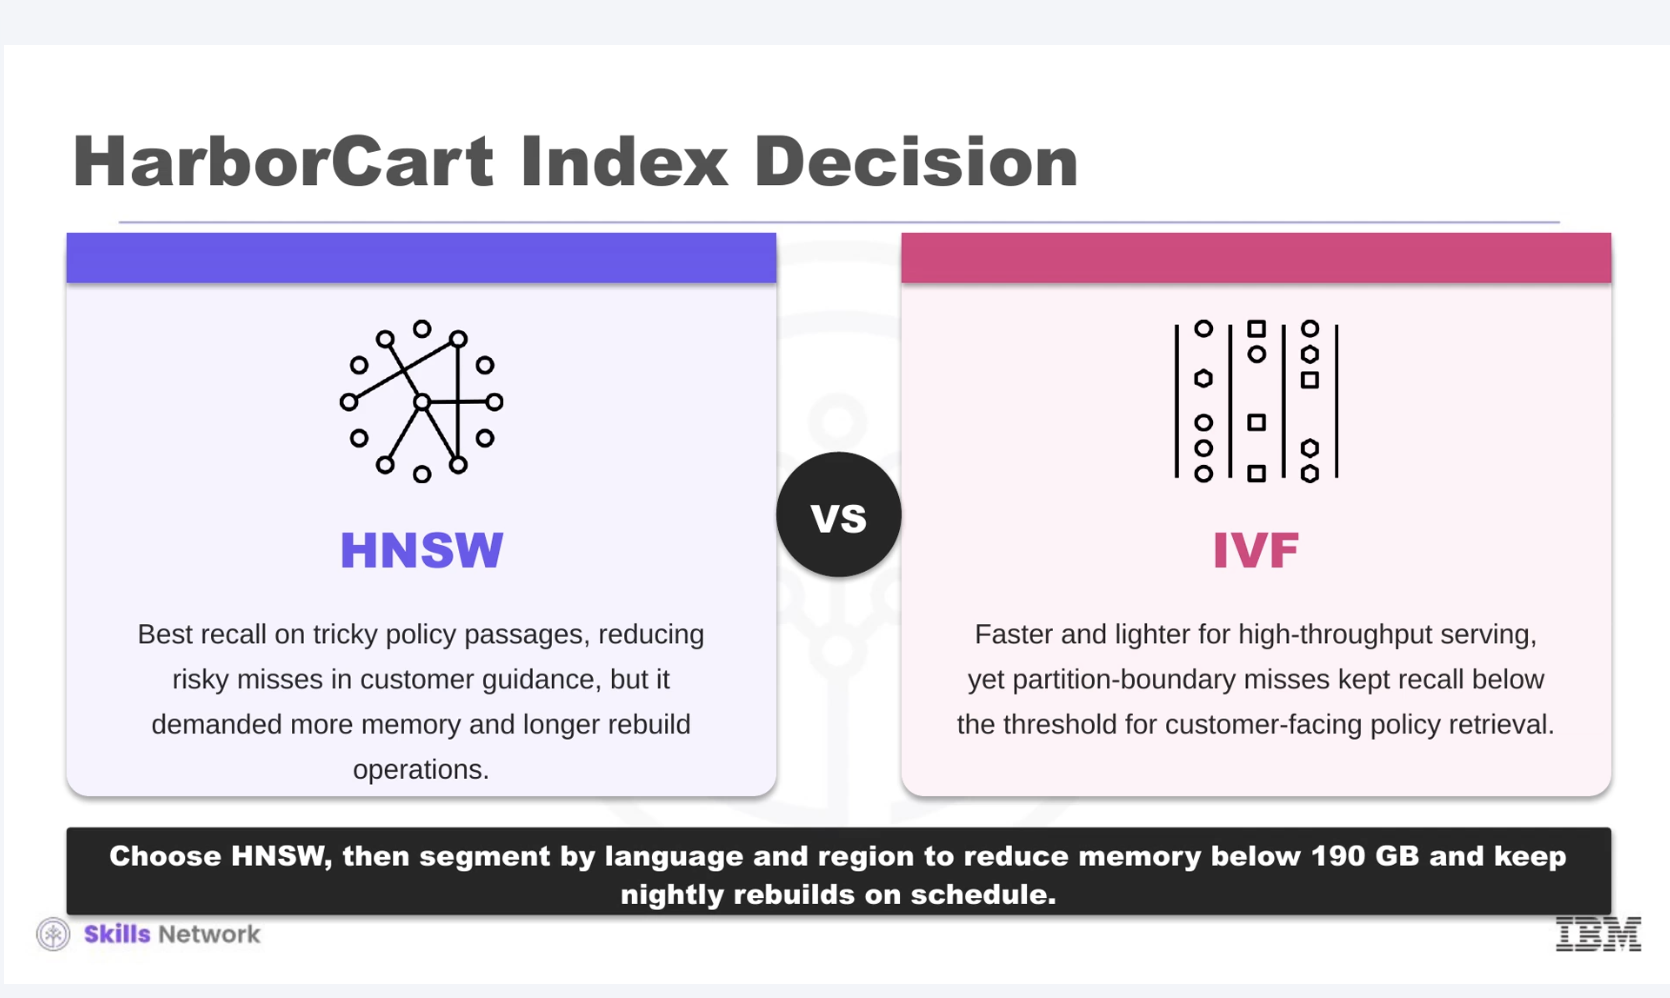
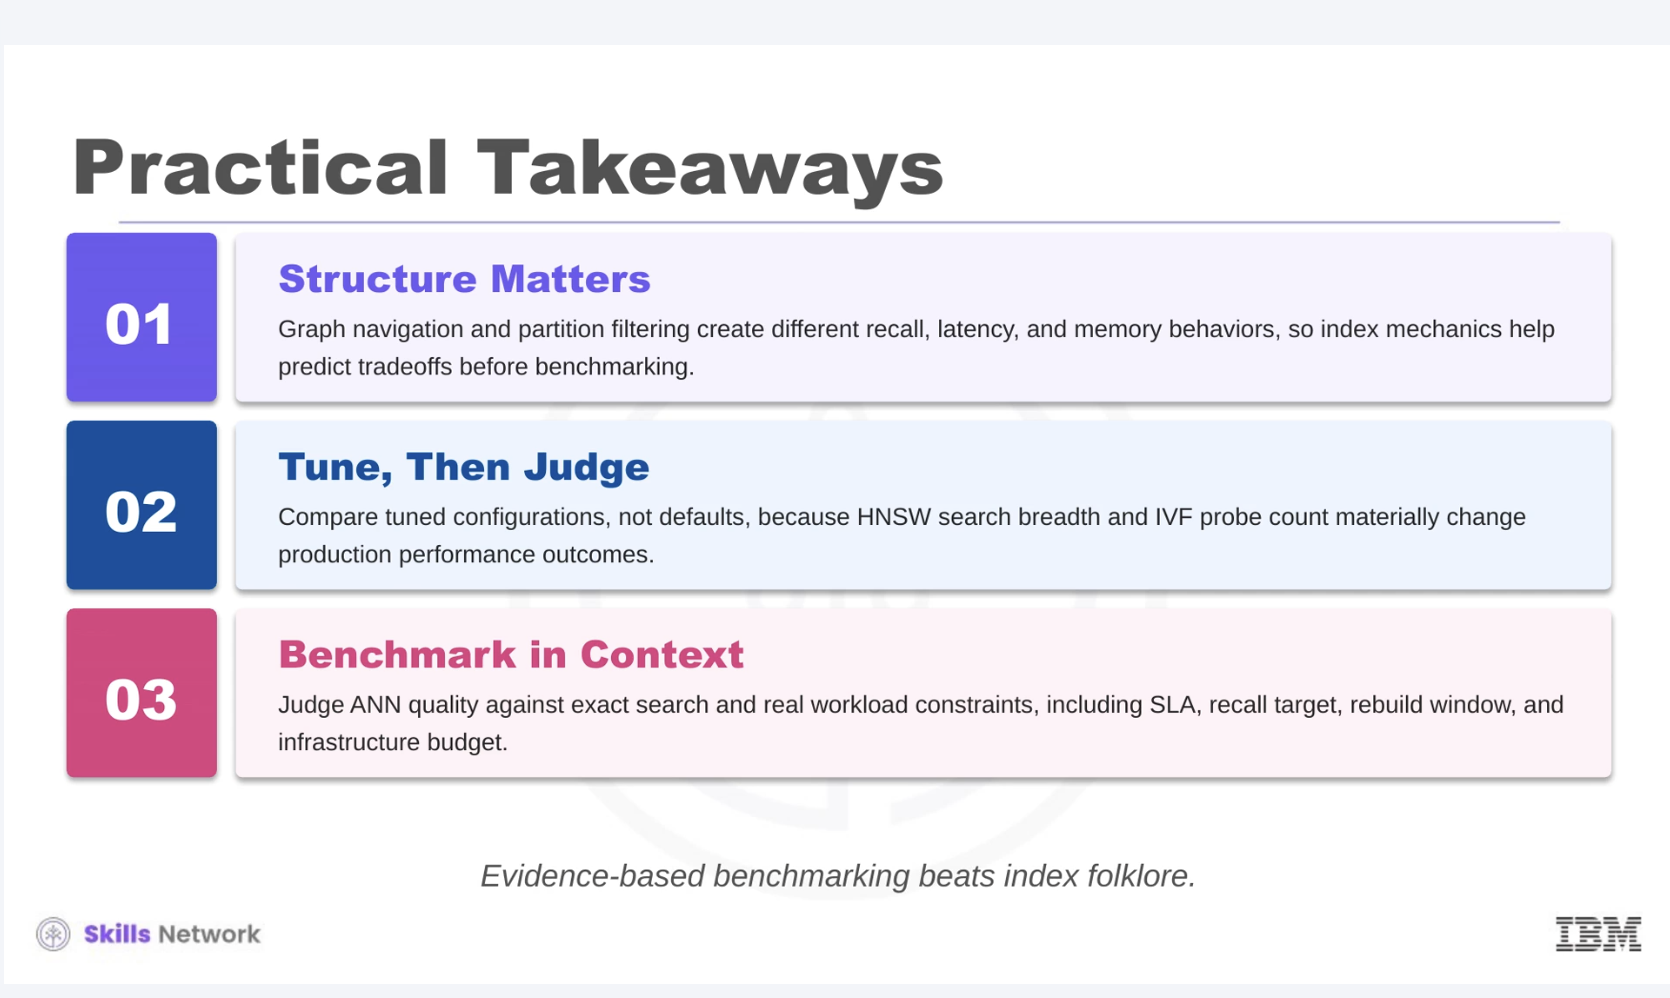

# [Practical_Lab](Practical1/benchmarking.ipynb)